# Kütüphaneler

In [ ]:
import pandas as pd
import numpy as np
import seaborn as sb
import missingno as msno
from sklearn.preprocessing import PowerTransformer
from sklearn.decomposition import PCA
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics.pairwise import cosine_similarity, euclidean_distances
import difflib
#Radar grafiği için aşağıdaki 2 kütüphane
import plotly.graph_objects as go
import pandas as pd

# Verinin Yüklenmesi Ve incelenmesi

In [ ]:
data = pd.read_csv("/content/players_data_light-2024_2025.csv")

In [ ]:
dt=data.copy()

In [ ]:
dt.head()

,Rk,Player,Nation,Pos,Squad,Comp,Age,Born,MP,Starts,...,Att (GK),Thr,Launch%,AvgLen,Opp,Stp,Stp%,#OPA,#OPA/90,AvgDist
0,1,Max Aarons,eng ENG,DF,Bournemouth,eng Premier League,24.0,2000.0,3,1,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2,Max Aarons,eng ENG,"DF,MF",Valencia,es La Liga,24.0,2000.0,4,1,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,3,Rodrigo Abajas,es ESP,DF,Valencia,es La Liga,21.0,2003.0,1,1,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,4,James Abankwah,ie IRL,"DF,MF",Udinese,it Serie A,20.0,2004.0,6,0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,5,Keyliane Abdallah,fr FRA,FW,Marseille,fr Ligue 1,18.0,2006.0,1,0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [ ]:
dt.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2854 entries, 0 to 2853
Columns: 165 entries, Rk to AvgDist
dtypes: float64(61), int64(99), object(5)
memory usage: 3.6+ MB


In [ ]:
dt.shape

(2854, 165)

Veri setimiz 2854 oyuncu ve 165 değişkenden oluşuyor.Amacım verideki gereksiz ve tekrar eden sütunları attıktan sonra Temel Bileşenler Analizi uygulamak.Çıkan Temel Bileşenler ile bir scout sistemi oluşturmak.

# Eksik Değer Analizi

In [ ]:
dt.isnull().sum().sum()

np.int64(86395)

In [ ]:
def eksik_deger_tablosu(dt):
  eksik_deger=dt.isnull().sum() #Her sütundaki eksik değerler
  eksik_deger_yuzde=100*dt.isnull().sum()/len(dt) #Her sütundaki eksik değer yüzdesi
  eksik_deger_tablo=pd.concat([eksik_deger,eksik_deger_yuzde],axis=1) #Eksik değer tablosu
  eksik_deger_tablo=eksik_deger_tablo.rename(columns={0:"Eksik Değerler",1:"Eksik Değer Yüzdesi"})
  eksik_deger_tablo=eksik_deger_tablo[eksik_deger_tablo.iloc[:,1]!=0].sort_values(by="Eksik Değer Yüzdesi",ascending=False)
  # Özet bilgileri yazdır
  print ("DATAMIZ " + str(dt.shape[1]) + " SÜTUNA SAHİP.\n"+str(eksik_deger_tablo.shape[0]) +
         " SÜTUNDA EKSİK DEĞER VAR")
  #Eksik bilgileri içeren veri çerçevesini döndürün
  return eksik_deger_tablo

Veri setimizde toplam 86395 adet eksik değer var.Bu eksik değerlerin olduğu satırları doğrudan silmek,ortalamayla veya medyanla doldurmak doğru değil.Öncelikle bu eksik değerlerin sebebini anlamaya çalışalım

In [ ]:
dt_eksik=eksik_deger_tablosu(dt)
dt_eksik

DATAMIZ 165 SÜTUNA SAHİP.
44 SÜTUNDA EKSİK DEĞER VAR


,Eksik Değerler,Eksik Değer Yüzdesi
CS%,2651,92.887176
Save%,2648,92.782060
PSxG/SoT,2648,92.782060
AvgDist,2646,92.711983
Cmp%_stats_keeper_adv,2644,92.641906
Stp%,2643,92.606868
GA,2642,92.571829
SoTA,2642,92.571829
PKatt_stats_keeper,2642,92.571829
CS,2642,92.571829


Kaleciliğe ait istatistiklerin büyük çoğunluğu boş çünkü kalecilik istatistikleri diğer mevki futbolcuları tarafından üretilmiyor.

Çok fazla eksik değerimiz olduğu için grafik ile bakalım ve eksik değerleri anlamaya çalışalım.

## Eksik Değer Görselleştirme

<Axes: >

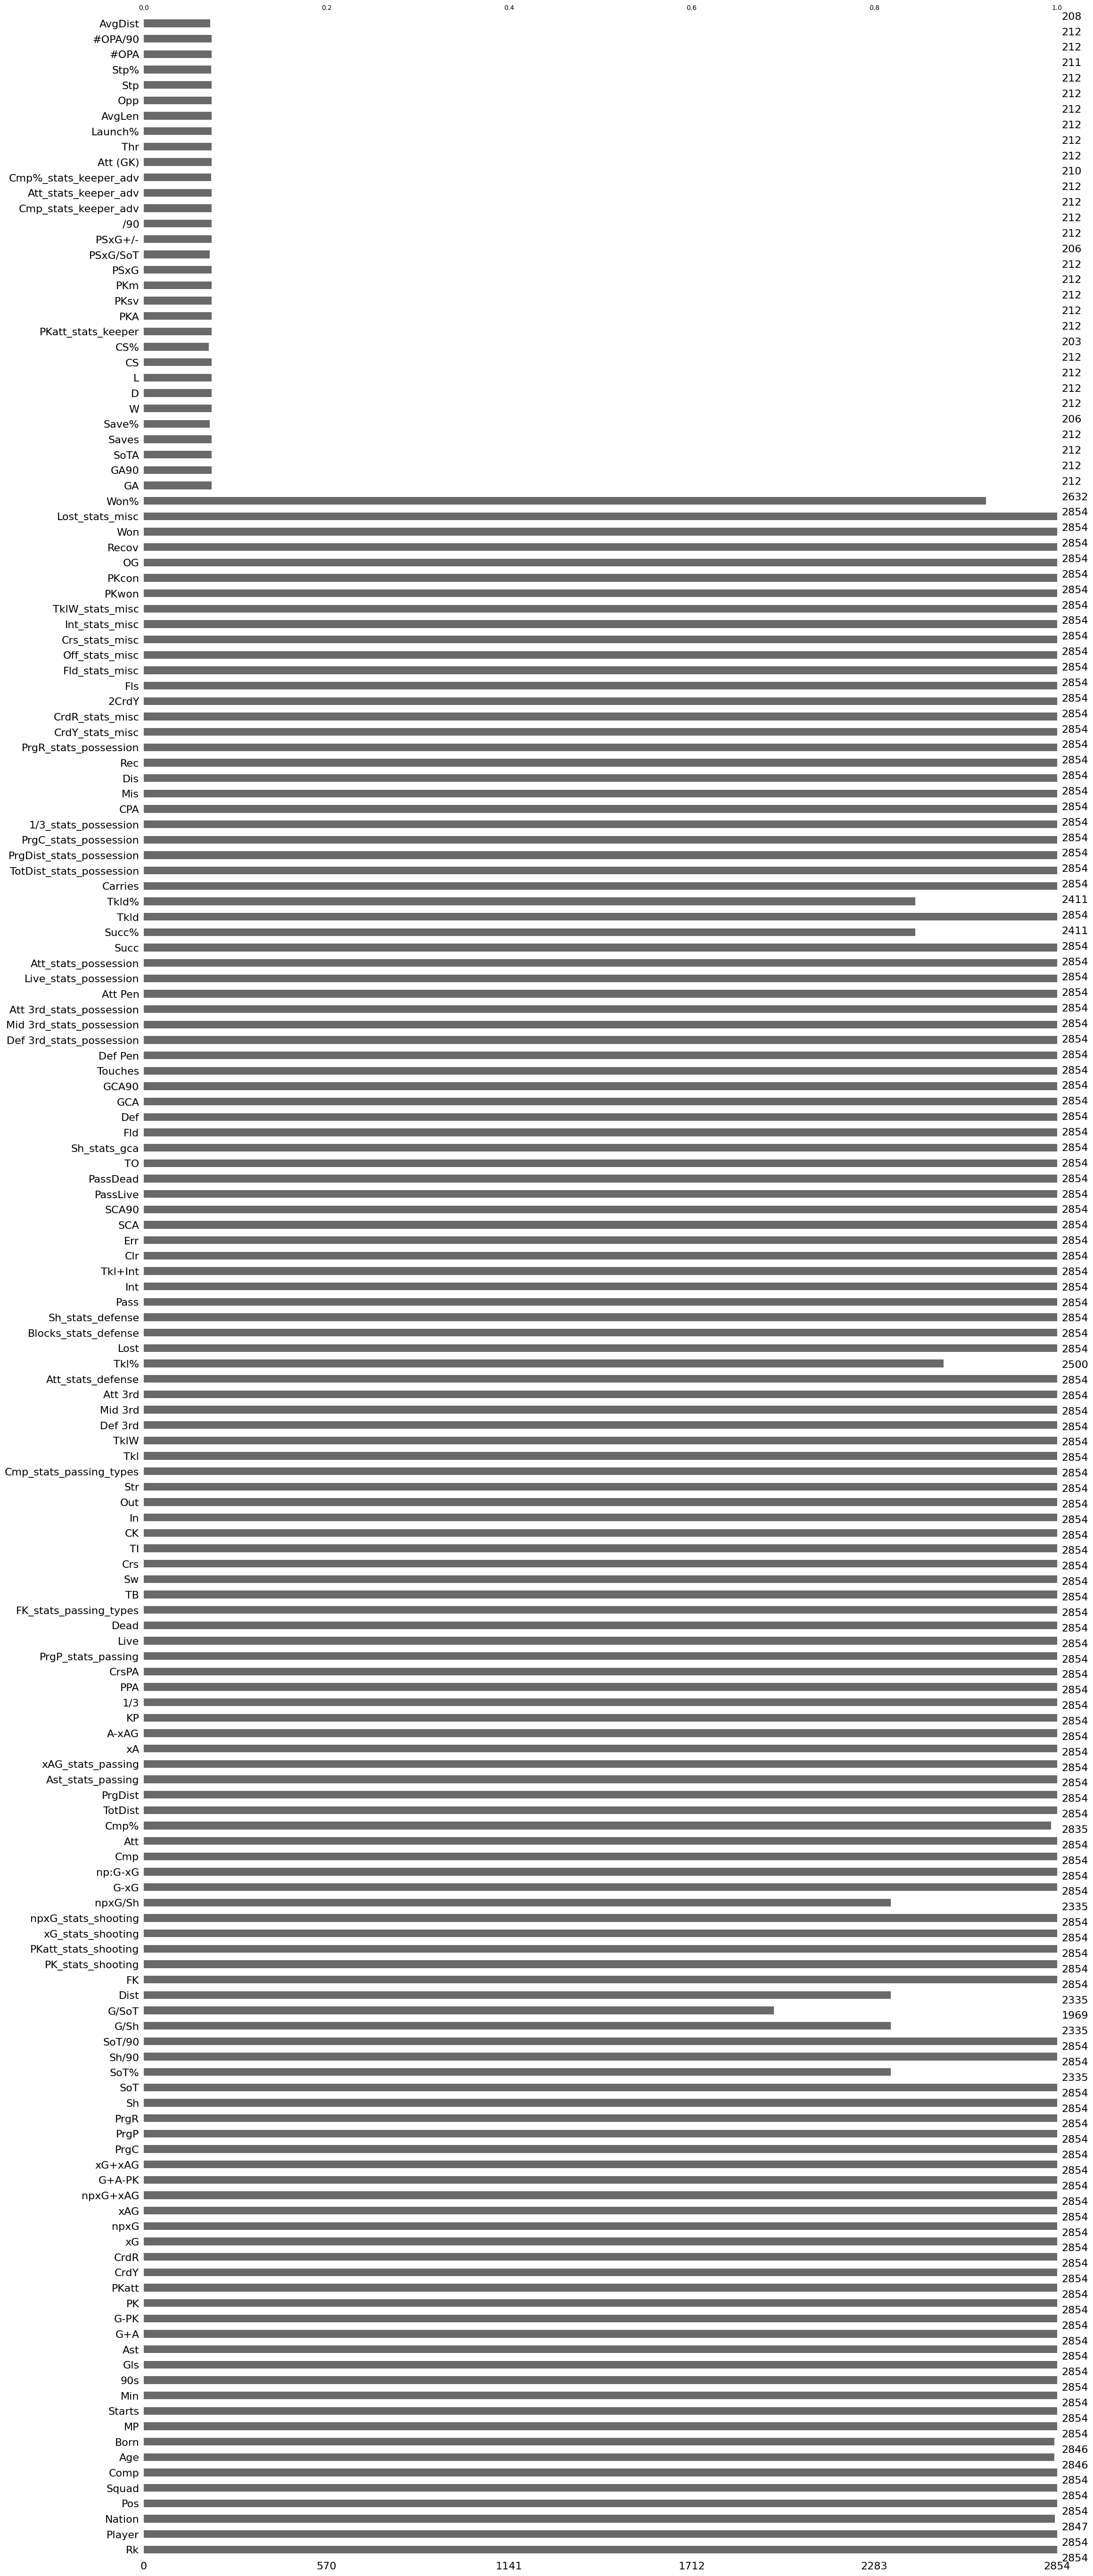

In [ ]:
msno.bar(dt) #Doluluk için

<Axes: >

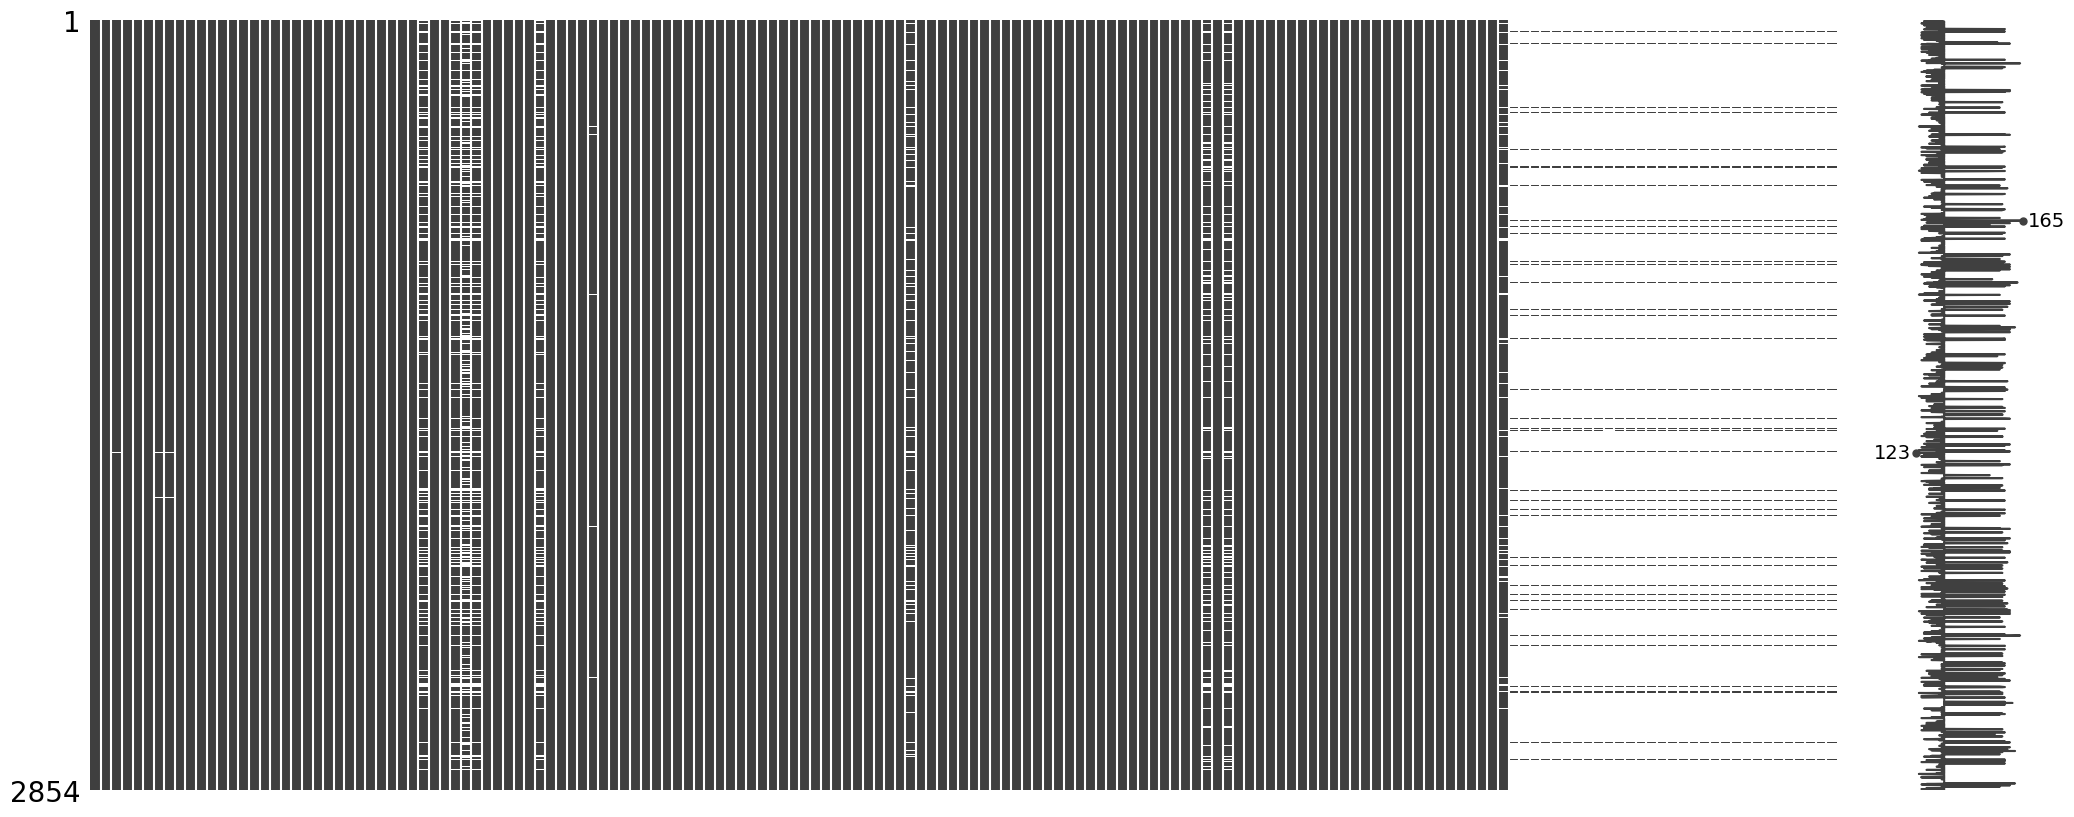

In [ ]:
msno.matrix(dt)
#Eksik gözlemlerin konumunun tespitini yaptık.En sağdaki boş sütunlar kaleci özellikleri olabilir.Birbirine çok benzer eksik sütunlar var

Bazı sütunlardaki eksik değerler birbirinin kopyası gibi bu sebeple sütunları paraçalara bölüp incelemek istiyorum."Missing at Random" durumu söz konusu olabilir.Bir sütundaki eksiklik diğer sütundaki eksikliğin doğrudan sebebi olabilir.

<Axes: >

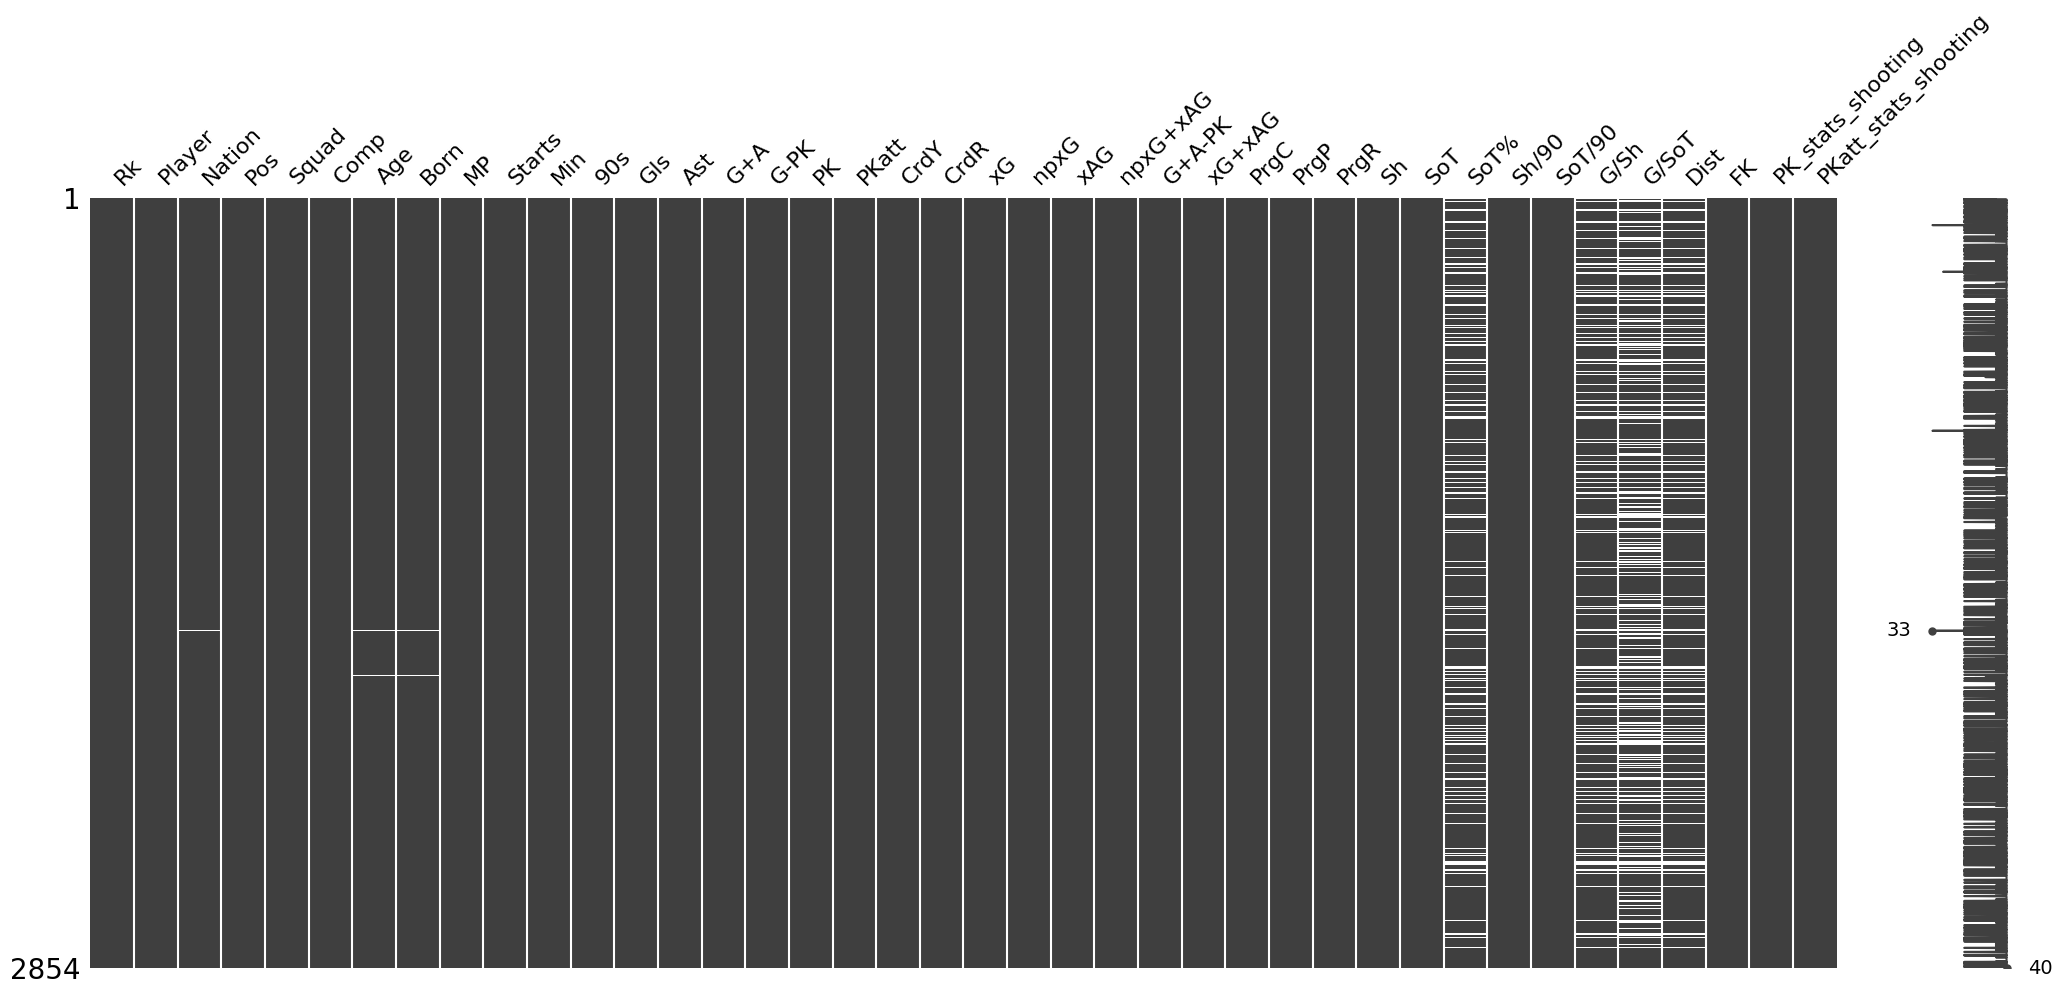

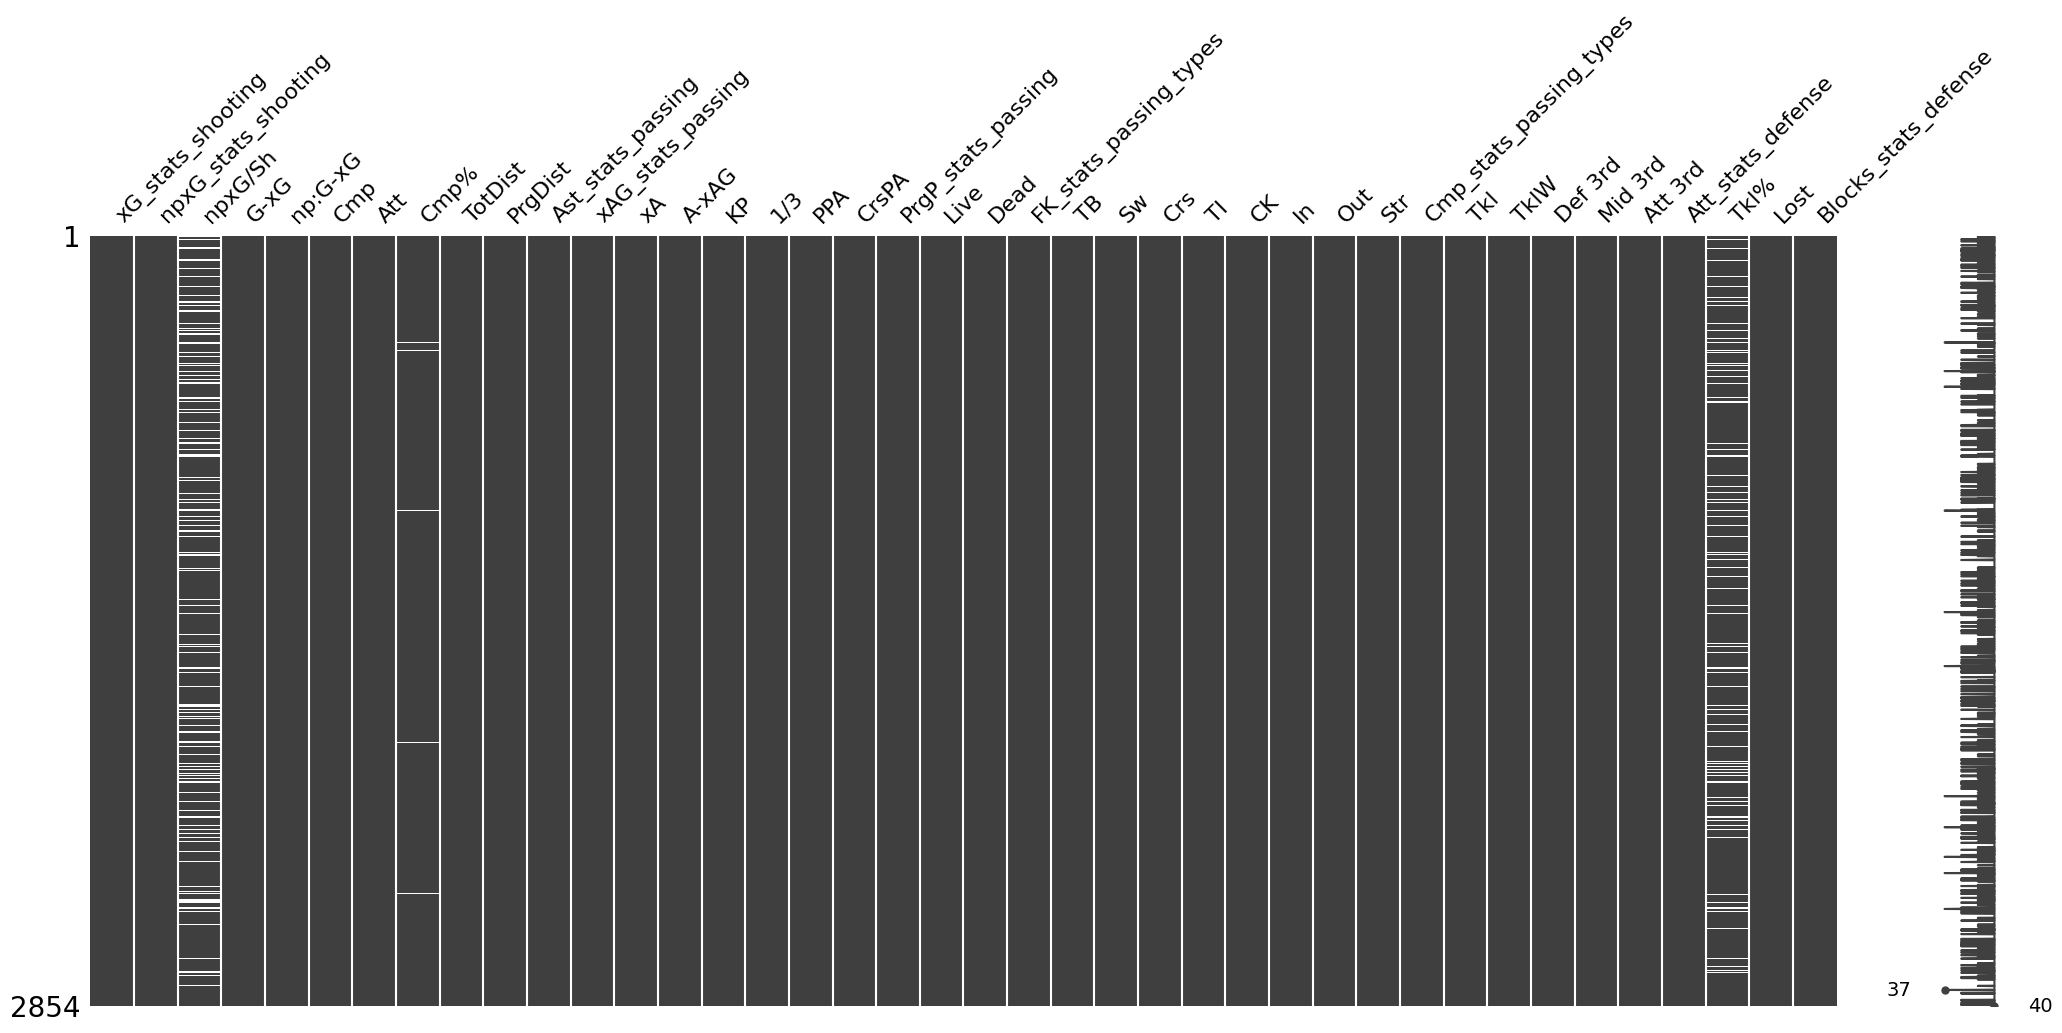

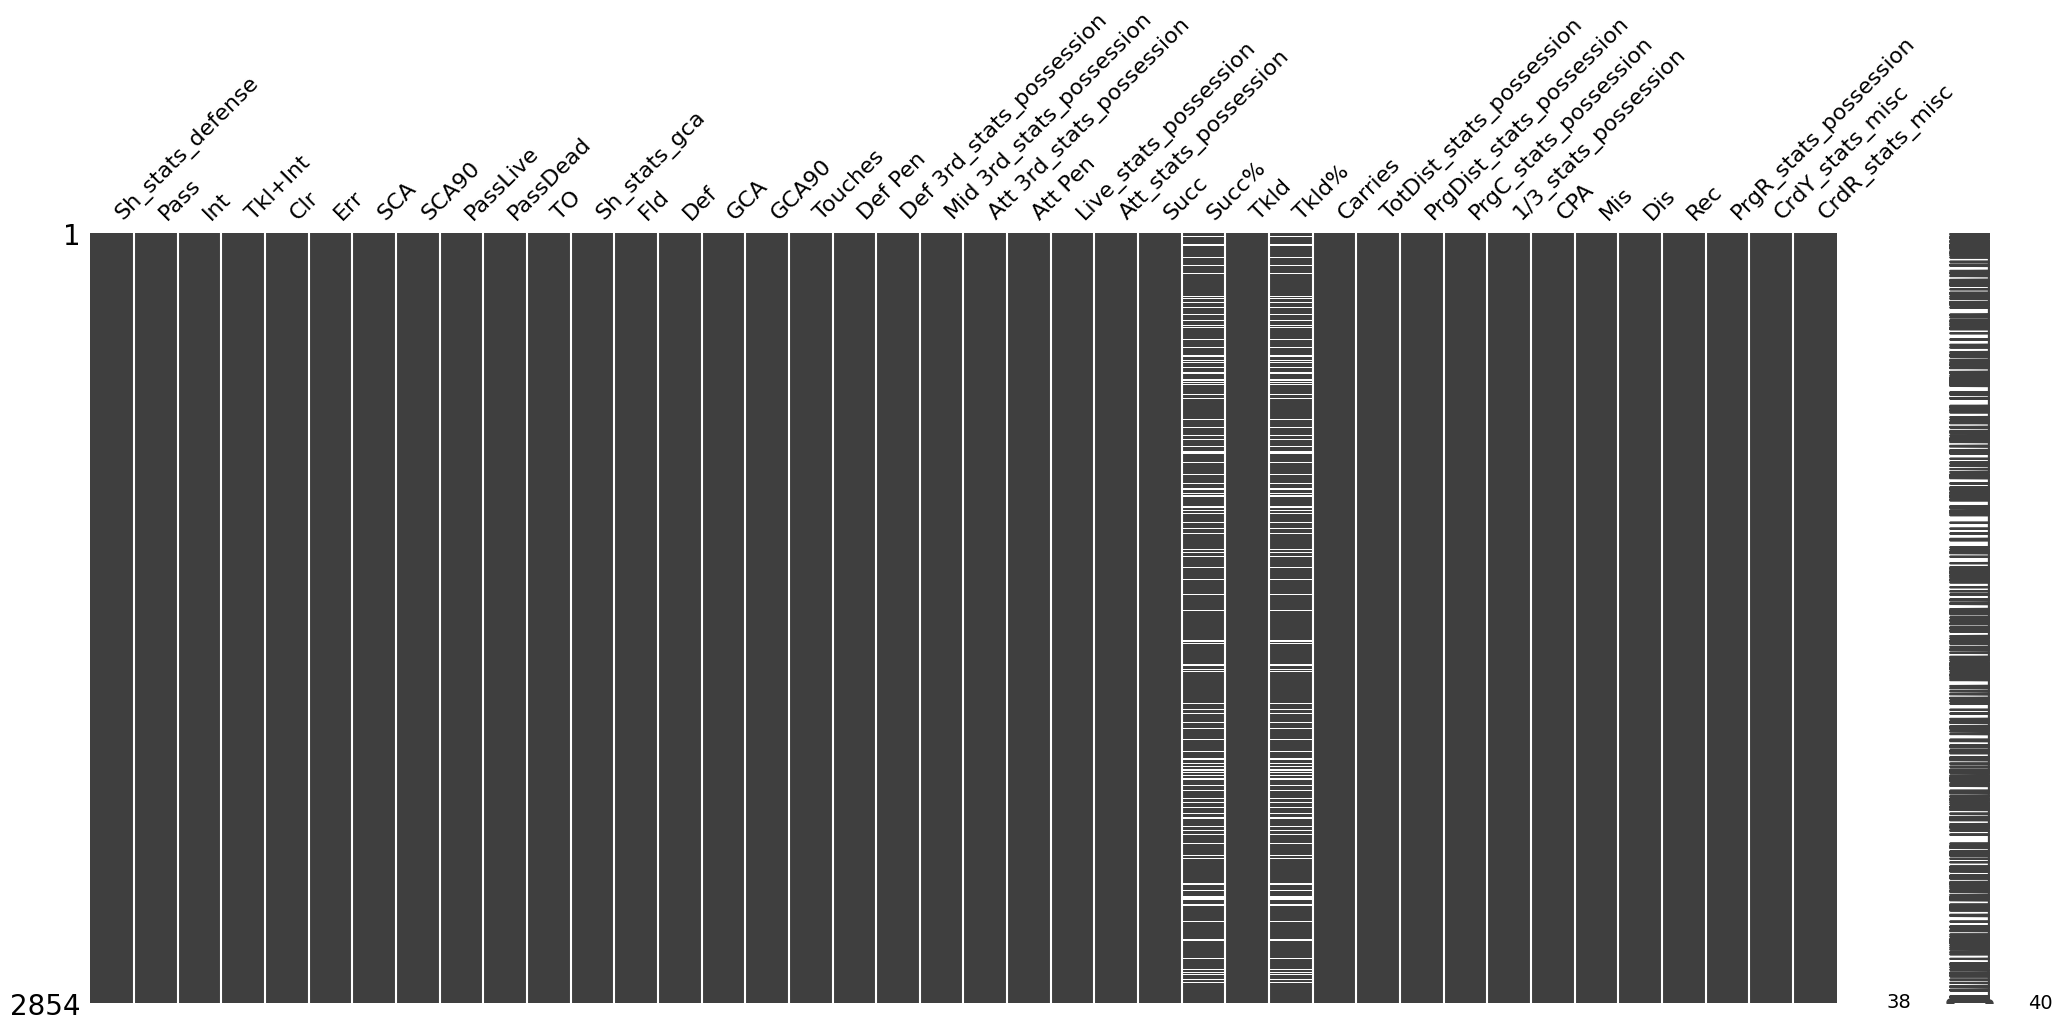

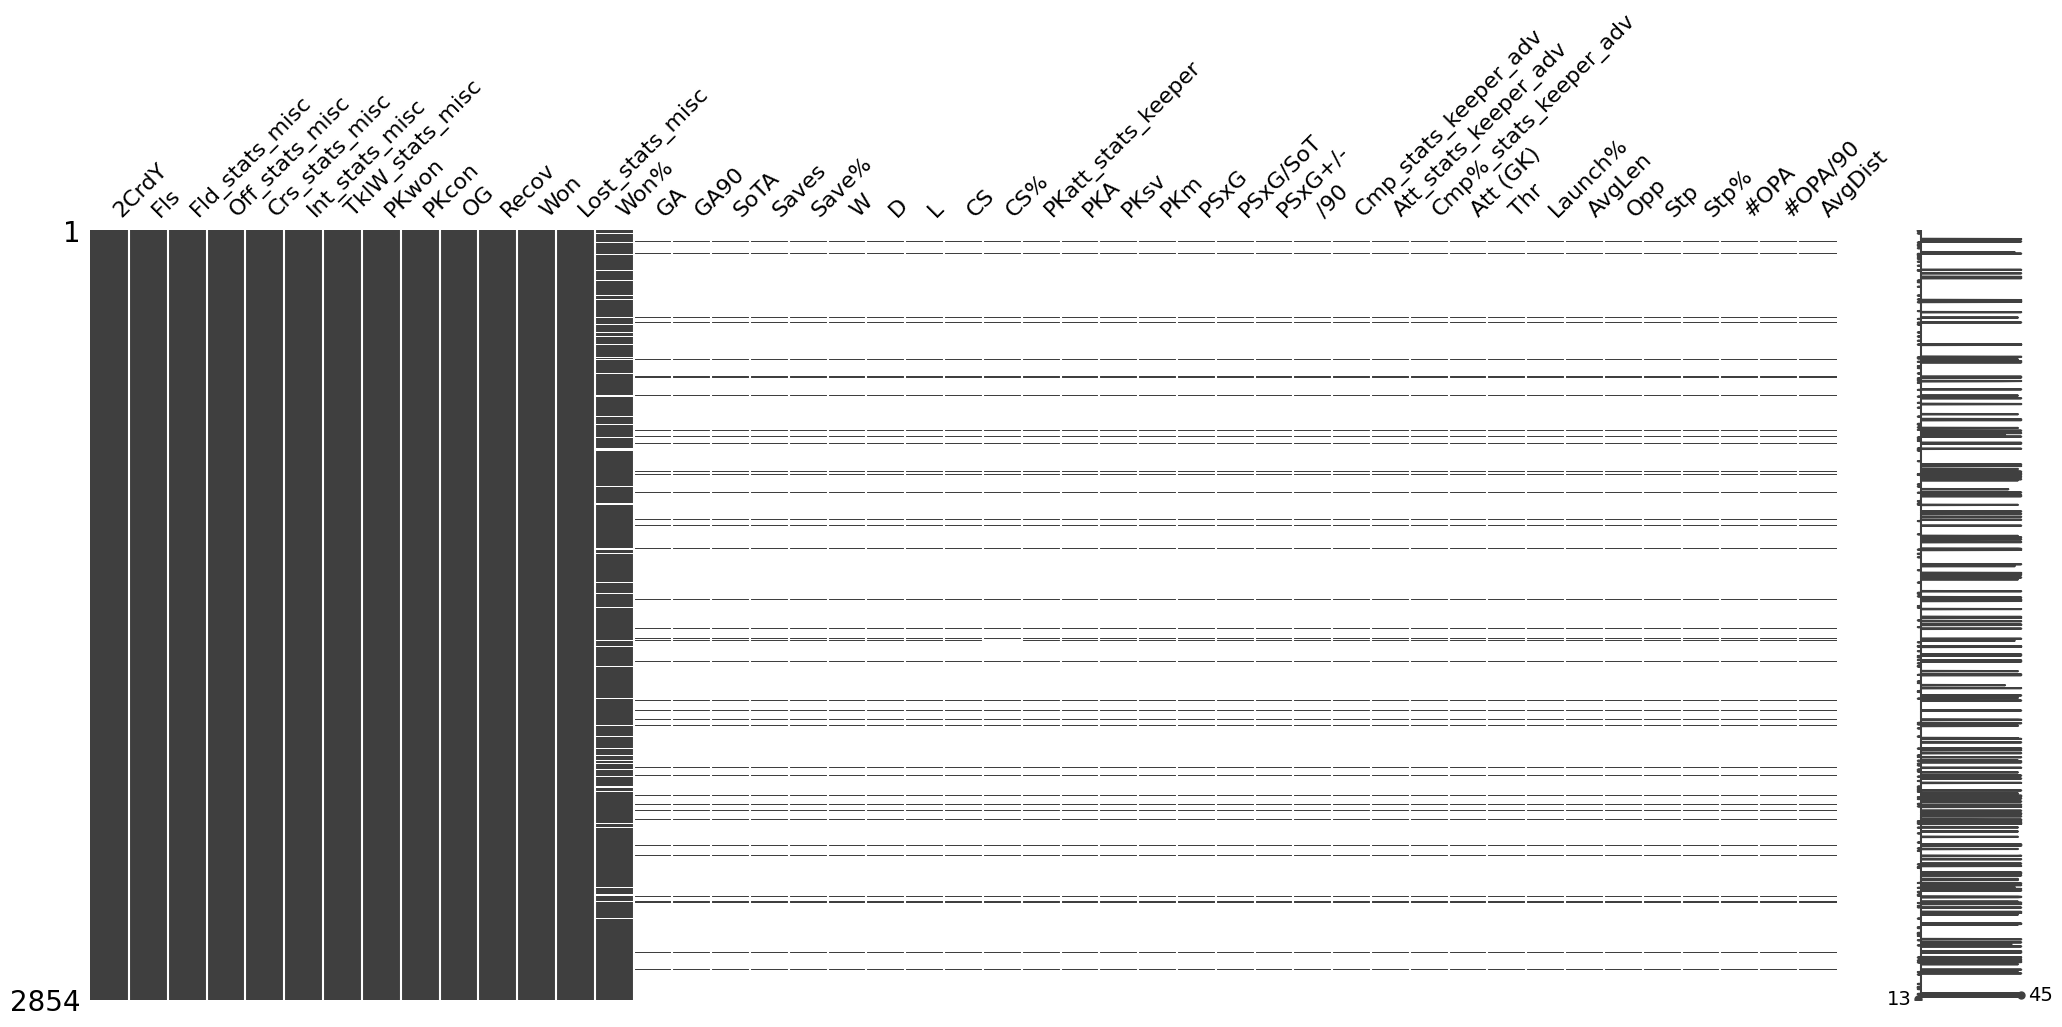

In [ ]:
msno.matrix(dt.iloc[:, 0:40])
msno.matrix(dt.iloc[:, 40:80])
msno.matrix(dt.iloc[:, 80:120])
msno.matrix(dt.iloc[:, 120:170])

<Axes: >

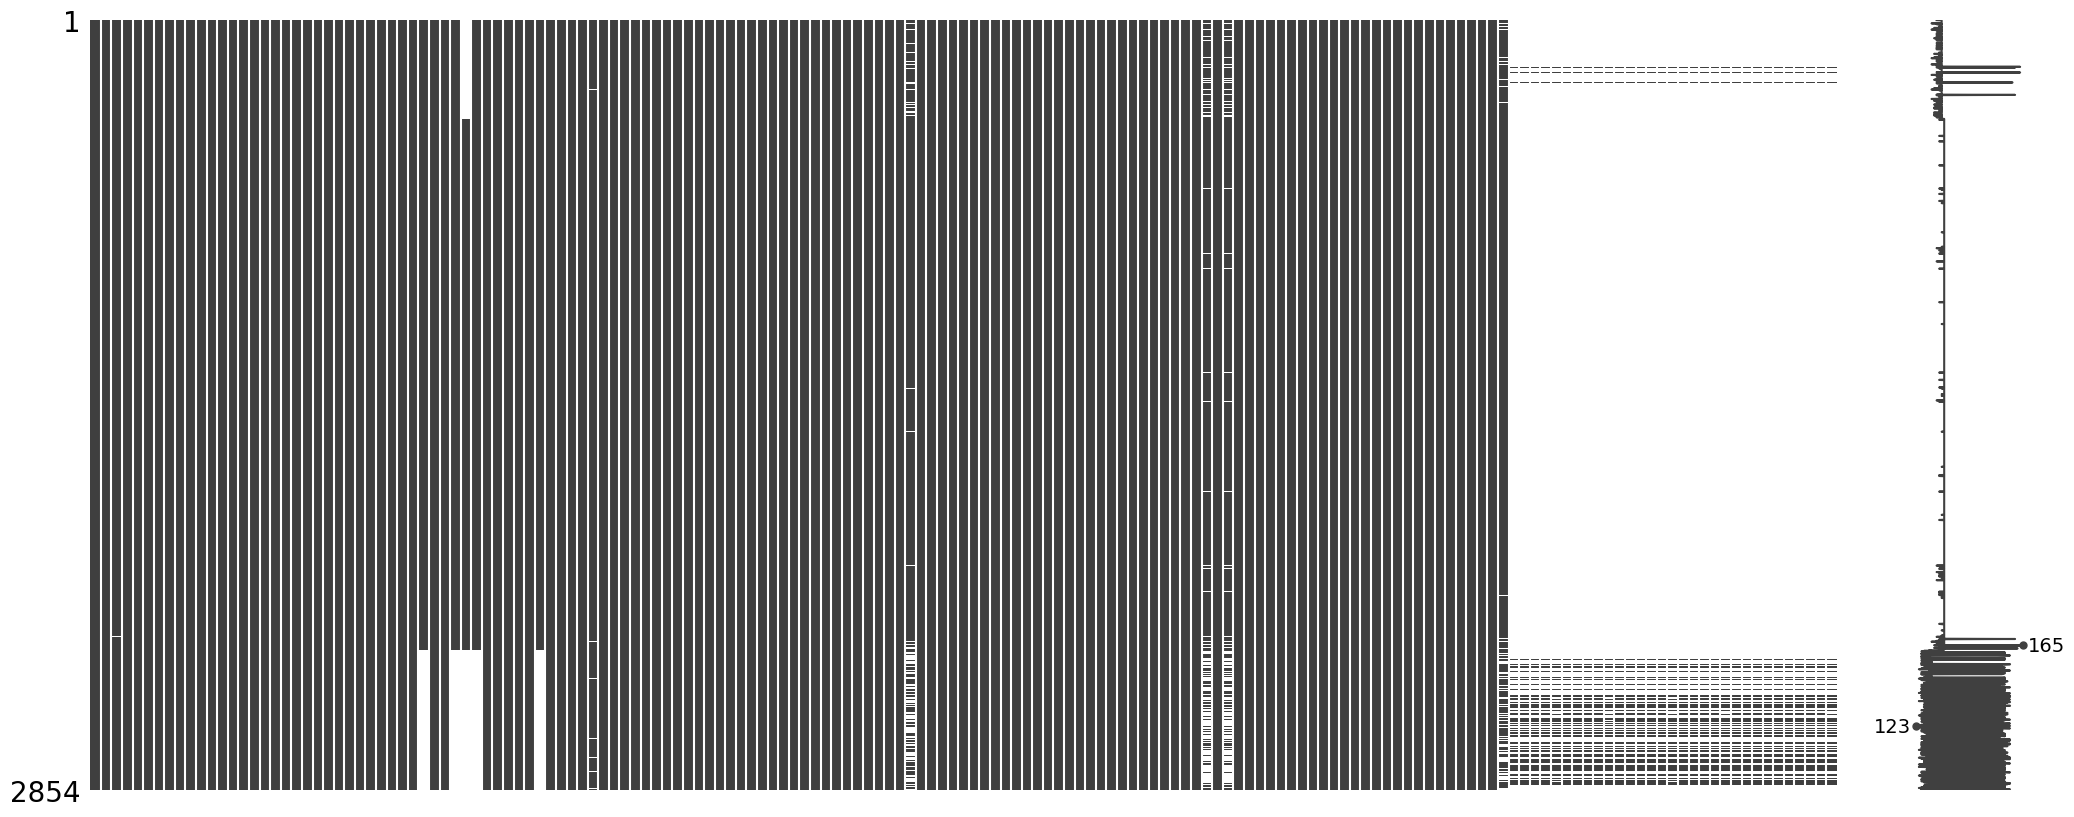

In [ ]:
sorted = dt.sort_values(by='SoT%',ascending=True) #SoT% degiskeni için örüntüyü daha net görebilmek için.
msno.matrix(sorted)

SoT%, G/Sh, G/SoT, npxG/Sh ve Dist gibi belirli oransal değişkenlerde birbirine paralel, sistematik eksiklik örüntüleri tespit ettim.Bu eksikliklerin bir veri kaybından ziyade, tanımsız matematiksel işlemlerden kaynaklandığı görülüyor. Örneğin; bir sezonda hiç şut çekmeyen (Sh = 0) oyuncular için "İsabetli Şut Yüzdesi" (SoT%), paydanın sıfır olması nedeniyle 0/0 formülüne girmekte ve sistem tarafından NaN (Not a Number) olarak atanmaktadır. Benzer şekilde, şut çeken ancak isabet bulamayan (SoT = 0) oyuncularda G/SoT (Gol/İsabetli Şut) metriği tanımsız kalmaktadır.

Bu oransal değişkenleri çıkaracağım çünkü taşıdıkları bilgi diğer sütunlarda var.

Dist şut mesafesini ölçtüğü için şut çekmeyen oyuncuların bu değişkeni eksik çıktı.Bunları 0 ile doldurmak hatalı olur çünkü anlamsızlaşır.
Eksik çıkan oyuncuların mevkisindeki dolu olan diğer oyuncuların ortalamasıyla doldurmak bir seçenek olabilir.

## Demografik Değişkenleri Manuel Olarak Doldurmak

In [ ]:
# Sadece Nation, Age veya Born sütunlarından herhangi biri eksik olan oyuncuları bulalım
eksik_oyuncular = dt[dt[['Nation', 'Age', 'Born']].isna().any(axis=1)]

# Sadece isimlerini ve eksik sütunları görelim
eksik_oyuncular[['Player', 'Nation', 'Age', 'Born']]

,Player,Nation,Age,Born
100,Olabade Aluko,NaN,NaN,NaN
273,Hannes Behrens,de GER,NaN,NaN
663,Pape Daouda Diongue,sn SEN,NaN,NaN
862,Jake Evans,NaN,NaN,NaN
1320,Atakan Karazor,NaN,27.0,1996.0
1518,Fer López,NaN,NaN,NaN
1603,Mateus Mane,NaN,NaN,NaN
1769,Max Moerstedt,de GER,NaN,NaN
1778,Jeremy Monga,NaN,NaN,NaN
1917,Plamedi Nsingi,NaN,23.0,2000.0


In [ ]:
dt["Nation"].unique() #Nation kısaltmalarını doğru doldurmak için kontrol edelim

array(['eng ENG', 'es ESP', 'ie IRL', 'fr FRA', 'ma MAR', 'dz ALG',
       'eg EGY', 'tn TUN', 'sa KSA', 'dk DEN', 'br BRA', 'it ITA',
       'ng NGA', 'sct SCO', 'us USA', 'at AUT', 'de GER', 'ci CIV',
       'me MNE', 'ch SUI', 'se SWE', 'gh GHA', 'no NOR', 'ro ROU',
       'nl NED', 'ar ARG', 'py PAR', 'ga GAB', 'pt POR', nan, 'mx MEX',
       'sn SEN', 'pa PAN', 'pr PUR', 'jm JAM', 'uy URU', 've VEN',
       'ht HAI', 'is ISL', 'jp JPN', 'al ALB', 'co COL', 'tg TOG',
       'id IDN', 'gn GUI', 'hr CRO', 'sl SLE', 'ca CAN', 'cd COD',
       'cm CMR', 'hu HUN', 'zm ZAM', 'cz CZE', 'be BEL', 'tr TUR',
       'sr SUR', 'pl POL', 'sk SVK', 'gw GNB', 'si SVN', 'ml MLI',
       'nir NIR', 'rs SRB', 'cl CHI', 'wls WAL', 'au AUS', 'nz NZL',
       'ec ECU', 'lu LUX', 'gm GAM', 'cg CGO', 'bd BAN', 'gq EQG',
       'cv CPV', 'ge GEO', 'mq MTQ', 'ba BIH', 'mk MKD', 'bf BFA',
       'gr GRE', 'ua UKR', 'cr CRC', 'my MAS', 'lt LTU', 'ru RUS',
       'do DOM', 'iq IRQ', 'kr KOR', 'ph PHI', 'bj BE

In [ ]:
#Tüm bilgileri (Nation, Age, Born) eksik olanlar
dt.loc[dt['Player'] == 'Olabade Aluko', ['Nation', 'Age', 'Born']] = ['eng ENG', 18.0, 2006.0]
dt.loc[dt['Player'] == 'Jake Evans', ['Nation', 'Age', 'Born']] = ['eng ENG', 15.0, 2008.0]
dt.loc[dt['Player'] == 'Fer López', ['Nation', 'Age', 'Born']] = ['es ESP', 20.0, 2004.0]
dt.loc[dt['Player'] == 'Mateus Mane', ['Nation', 'Age', 'Born']] = ['pt POR', 16.0, 2007.0]
dt.loc[dt['Player'] == 'Jeremy Monga', ['Nation', 'Age', 'Born']] = ['eng ENG', 14.0, 2009.0]

#Sadece Yaş (Age) ve Doğum Yılı (Born) eksik olanlar
dt.loc[dt['Player'] == 'Hannes Behrens', ['Age', 'Born']] = [34.0, 1990.0]
dt.loc[dt['Player'] == 'Pape Daouda Diongue', ['Age', 'Born']] = [18.0, 2006.0]
dt.loc[dt['Player'] == 'Max Moerstedt', ['Age', 'Born']] = [18.0, 2006.0]

# Sadece Uyruk (Nation) bilgisi eksik olanlar
dt.loc[dt['Player'] == 'Atakan Karazor', 'Nation'] = 'tr TUR'
dt.loc[dt['Player'] == 'Plamedi Nsingi', 'Nation'] = 'cd COD'

In [ ]:
# Kalan eksik demografik veri kontrolü
kalan_eksik = dt[['Nation', 'Age', 'Born']].isna().sum().sum()
print(f"Demografik değişkenlerde kalan eksik veri sayısı: {kalan_eksik}")

Demografik değişkenlerde kalan eksik veri sayısı: 0


Manuel olarak çözmemiz gereken eksiklikleri çözdük.

Kalecileri veri setimizden çıkarmalıyız.

In [ ]:
dt_Gk=dt[dt["Pos"]=="GK"].copy()
dt_kalanlar=dt[dt["Pos"]!="GK"].copy()
#Saha içi oyuncularından kaleci sütunlarını atalaım
kaleci_sutunlari = ['GA', 'GA90', 'SoTA', 'Saves', 'Save%', 'W', 'D', 'L', 'CS', 'CS%',
    'PKatt_stats_keeper', 'PKA', 'PKsv', 'PKm', 'PSxG', 'PSxG/SoT', 'PSxG+/-',
    '/90', 'Cmp_stats_keeper_adv', 'Att_stats_keeper_adv', 'Cmp%_stats_keeper_adv',
    'Att (GK)', 'Thr', 'Launch%', 'AvgLen', 'Opp', 'Stp', 'Stp%', '#OPA', '#OPA/90', 'AvgDist'
]
atilacaklar = ["Tkld%", "Succ%", "Tkl%", "Won%", "npxG/Sh", "G/Sh", "G/SoT", "SoT%", "Dist"]
dt_kalanlar = dt_kalanlar.drop(columns=atilacaklar+kaleci_sutunlari)
# Şimdi oransal değişkenleri ve Dist sütununu atalım.Kaleciler için oluşturduğumuz datayı sadece kaleci özelliklerinden oluşturalım

In [ ]:
# Kaleciler için Whitelist (Sadece işimize yarayanları tutuyoruz)
kaleci_icin_secilenler = [
    'Player', 'Nation', 'Pos', 'Squad', 'Comp', 'Age', 'Born', 'MP', 'Starts', 'Min', '90s', # Künye
    'GA', 'GA90', 'SoTA', 'Saves', 'Save%', 'W', 'D', 'L', 'CS', 'CS%', 'PKatt_stats_keeper', 'PKA', 'PKsv', 'PKm', # Klasik Kaleci
    'PSxG', 'PSxG/SoT', 'PSxG+/-', '/90', # Gelişmiş Kaleci
    'Cmp_stats_keeper_adv', 'Att_stats_keeper_adv', 'Cmp%_stats_keeper_adv', 'Att (GK)', 'Thr', 'Launch%', 'AvgLen', # Dağıtım
    'Opp', 'Stp', 'Stp%', '#OPA', '#OPA/90', 'AvgDist', # Süpürücü Kaleci (Sweeper)
    'Touches', 'Def Pen', 'Def 3rd_stats_possession', 'Cmp', 'Att', 'Cmp%', 'TotDist', 'PrgDist', 'Clr', 'Recov', 'Err' # Pasör Kaleci Saha İçi Katkısı
]
dt_Gk = dt_Gk[kaleci_icin_secilenler].copy()

Pas isabet yüzdesi (Cmp%) değişkenindeki eksikliklerin, istatistiksel olarak anlamlı bir oynama süresi alamayan oyunculardan kaynaklandığını düşünüyorum.Bunu doğrulamak adına öncelikle ilgili satırlar tespit edilerek maç/dakika oranları test edeceğim.

In [ ]:
dt_kalanlar['Cmp%'].isna().sum()

np.int64(19)

19 tane oyuncu için bu sütun eksik

In [ ]:
#Pas verisi NaN olanları bulalım ve kaç dakika oynadıklarına bakalım.
etkisiz_oyuncular=dt_kalanlar[dt_kalanlar["Cmp%"].isna()]
#Sadece isim , maç sayısı ve oynadıkları dakikaya bakalım
print(etkisiz_oyuncular[["Player","MP","Min"]])

                     Player  MP  Min
394        Anthony Briançon   1    1
424   Nathan Butler-Oyedeji   1    7
500            Kaelan Casey   1    1
558   Aaron Ciammaglichella   1    1
1017        Michael Golding   1    1
1393      Kacper Koscierski   1    7
1593          Aaron Malouda   1    2
1734        Shumaira Mheuka   1    1
1877           Reiss Nelson   1    3
1905            Adrian Niño   1   12
2075   Faris Pemi Moumbagna   1    8
2190       Remy Rees-Dottin   1    1
2300             Faik Sakar   1    1
2360           Saba Sazonov   1    3
2437         Ayanda Sishuba   1    3
2493         Jay Stansfield   1    1
2624        Boubacar Traoré   1    1
2793           Daniel Yáñez   1    2
2830         Alessio Zerbin   2    2


Düşündüğümüz gibi bu oyuncular çok az süre almış oyunculardan oluşuyor.Zaten devamında çok az süre alan oyuncuları çıkaracağız.YİNE DE EKSİK GÖZLEMLERİ TEMİZLERKEN BU AZ SÜRE ALMIŞ OYUNCULARI ÇIKARIYORUM.

In [ ]:
dt_kalanlar = dt_kalanlar[dt_kalanlar['Cmp%'].notna()]

In [ ]:
#Index Sıfırlama Ve Son Kontrol
dt_kalanlar = dt_kalanlar.reset_index(drop=True)
dt_Gk = dt_Gk.reset_index(drop=True)

print(f"-> Saha İçi Oyuncuları Veri Seti (dt_kalanlar) Boyutu: {dt_kalanlar.shape}")
print(f"-> Saha İçi Oyuncularında Kalan Eksik Veri (NaN): {dt_kalanlar.isna().sum().sum()}\n")

print(f"-> Kaleci Veri Seti (dt_Gk) Boyutu: {dt_Gk.shape}")
print(f"-> Kalecilerde Kalan Eksik Veri (NaN): {dt_Gk.isna().sum().sum()}")

-> Saha İçi Oyuncuları Veri Seti (dt_kalanlar) Boyutu: (2623, 125)
-> Saha İçi Oyuncularında Kalan Eksik Veri (NaN): 0

-> Kaleci Veri Seti (dt_Gk) Boyutu: (212, 53)
-> Kalecilerde Kalan Eksik Veri (NaN): 28


Kaleciler datamızda 28 eksik gözlem hala var.Bu eksikleri incelememiz gerekiyor.

In [ ]:
eksik_sutunlar_gk = dt_Gk.isna().sum()
print("Eksik Veri Barındıran Kaleci Sütunları:")
print(eksik_sutunlar_gk[eksik_sutunlar_gk > 0])
# 2. Hangi KALECİLERDE eksik var? (İsimlerini ve Oynadıkları Dakikayı görelim)
eksik_kaleciler = dt_Gk[dt_Gk.isna().any(axis=1)]
print("Eksik Verisi Olan Kaleciler ve Oynadıkları Süreler (Min):")
print(eksik_kaleciler[['Player', 'Min']])

Eksik Veri Barındıran Kaleci Sütunları:
Save%                    6
CS%                      9
PSxG/SoT                 6
Cmp%_stats_keeper_adv    2
Stp%                     1
AvgDist                  4
dtype: int64
Eksik Verisi Olan Kaleciler ve Oynadıkları Süreler (Min):
                 Player  Min
2    Ben Alexander Voll   91
26      Giuseppe Ciocci    9
39       Álex Domínguez   19
54      Gauthier Gallon   45
72      Vitezslav Jaros   12
79             Tom King    1
93            Pau López   45
104        Andrea Mazza    8
176       Tobias Sippel   59
179   Daniele Sommariva   28
196        Sven Ulreich   90


In [ ]:
dt_Gk = dt_Gk[dt_Gk['Min'] >=92]

In [ ]:
dt_kalanlar = dt_kalanlar.reset_index(drop=True)
dt_Gk = dt_Gk.reset_index(drop=True)

In [ ]:
print("VERİ ÖN İŞLEME: FİNAL KONTROL RAPORU")
print("=" * 55)

print("SAHA İÇİ OYUNCULARI (dt_kalanlar):")
print(f" -> Veri Seti Boyutu (Satır, Sütun) : {dt_kalanlar.shape}")
print(f" -> Kalan Toplam Eksik Veri (NaN)  : {dt_kalanlar.isna().sum().sum()}")

print("-" * 55)

print("KALECİLER (dt_Gk):")
print(f" -> Veri Seti Boyutu (Satır, Sütun) : {dt_Gk.shape}")
print(f" -> Kalan Toplam Eksik Veri (NaN)  : {dt_Gk.isna().sum().sum()}")
print("=" * 55)

VERİ ÖN İŞLEME: FİNAL KONTROL RAPORU
SAHA İÇİ OYUNCULARI (dt_kalanlar):
 -> Veri Seti Boyutu (Satır, Sütun) : (2623, 125)
 -> Kalan Toplam Eksik Veri (NaN)  : 0
-------------------------------------------------------
KALECİLER (dt_Gk):
 -> Veri Seti Boyutu (Satır, Sütun) : (188, 53)
 -> Kalan Toplam Eksik Veri (NaN)  : 0


Kaleciler için küçük bir dakika filtresi koydum.Şimdilik eksik verilerden kurtulmak için.Projenin devamında daha geniş kapsamlı bir dakika filtresi uygulayacağım.

Eksik değerimiz kalmadı.

## Tekrar Eden Oyuncular

In [ ]:
print(dt_kalanlar[dt_kalanlar.duplicated()]) #Duplicated veri vermez.True False döndürür.drop_duplicates ise true olan veriyi siler.

Empty DataFrame
Columns: [Rk, Player, Nation, Pos, Squad, Comp, Age, Born, MP, Starts, Min, 90s, Gls, Ast, G+A, G-PK, PK, PKatt, CrdY, CrdR, xG, npxG, xAG, npxG+xAG, G+A-PK, xG+xAG, PrgC, PrgP, PrgR, Sh, SoT, Sh/90, SoT/90, FK, PK_stats_shooting, PKatt_stats_shooting, xG_stats_shooting, npxG_stats_shooting, G-xG, np:G-xG, Cmp, Att, Cmp%, TotDist, PrgDist, Ast_stats_passing, xAG_stats_passing, xA, A-xAG, KP, 1/3, PPA, CrsPA, PrgP_stats_passing, Live, Dead, FK_stats_passing_types, TB, Sw, Crs, TI, CK, In, Out, Str, Cmp_stats_passing_types, Tkl, TklW, Def 3rd, Mid 3rd, Att 3rd, Att_stats_defense, Lost, Blocks_stats_defense, Sh_stats_defense, Pass, Int, Tkl+Int, Clr, Err, SCA, SCA90, PassLive, PassDead, TO, Sh_stats_gca, Fld, Def, GCA, GCA90, Touches, Def Pen, Def 3rd_stats_possession, Mid 3rd_stats_possession, Att 3rd_stats_possession, Att Pen, Live_stats_possession, Att_stats_possession, Succ, Tkld, ...]
Index: []

[0 rows x 125 columns]


In [ ]:
tekrar_edenler=dt_kalanlar[dt_kalanlar.duplicated(subset="Player")]
print(tekrar_edenler)

        Rk                  Player   Nation    Pos            Squad  \
1        2              Max Aarons  eng ENG  DF,MF         Valencia   
18      19           Tammy Abraham  eng ENG     FW            Milan   
23      24              Akor Adams   ng NGA     FW      Montpellier   
38      40        Emmanuel Agbadou   ci CIV     DF            Reims   
52      55            Joseph Aidoo   gh GHA     DF       Celta Vigo   
76      79          Carlos Alcaraz   ar ARG  FW,MF          Everton   
79      82            Carles Aleñá   es ESP  MF,FW           Alavés   
112    117       Samuel Amo-Ameyaw  eng ENG  DF,MF       Strasbourg   
114    119          Mathis Amougou   fr FRA     MF    Saint-Étienne   
118    123        Joachim Andersen   dk DEN     DF           Fulham   
133    138                  Antony   br BRA     FW            Betis   
159    166           Marco Asensio   es ESP  FW,MF        Paris S-G   
176    186             Jordan Ayew   gh GHA  FW,MF   Leicester City   
180   

Datasetimizde bazı oyuncular tekrar ediyor.Bunun sebebi oyuncunun o sezon iki takımda oynaması yani transfer olmasından kaynaklanıyor.En fazla süre aldığı satırı alacağız.Diğerini ayıracağız.

In [ ]:
# 1. Veriyi süreye göre büyükten küçüğe sıralıyoruz (En çok süre alan en üste gelir)
dt_sirali=dt_kalanlar.sort_values(by="Min",ascending=False) #  Azalan şekilde sıraladık

#Her oyuncunun sadece en yüksek süreli (ilk) kaydını alıyoruz
dt_model=dt_sirali.drop_duplicates(subset="Player",keep="first").copy()

# Transfer Yedek Seti(Az süre alınan): Ana sete girmeyen tüm 'tekrar eden' satırları buraya ayırıyoruz
dt_transfer_yedek=dt_sirali[~dt_sirali.index.isin(dt_model.index)].copy()
# 4. İndeksleri sıfırlayalım (Temiz bir başlangıç için)
dt_model = dt_model.reset_index(drop=True)
dt_transfer_yedek = dt_transfer_yedek.reset_index(drop=True)

In [ ]:
print(f"Modelleme Seti (Eşsiz Oyuncu): {dt_model.shape[0]} satır")
print(f"Transfer Yedek Seti (Ekstra Kayıtlar): {dt_transfer_yedek.shape[0]} satır")

Modelleme Seti (Eşsiz Oyuncu): 2477 satır
Transfer Yedek Seti (Ekstra Kayıtlar): 146 satır


In [ ]:
print(dt_model.columns.tolist()) #Sütun isimleri

['Rk', 'Player', 'Nation', 'Pos', 'Squad', 'Comp', 'Age', 'Born', 'MP', 'Starts', 'Min', '90s', 'Gls', 'Ast', 'G+A', 'G-PK', 'PK', 'PKatt', 'CrdY', 'CrdR', 'xG', 'npxG', 'xAG', 'npxG+xAG', 'G+A-PK', 'xG+xAG', 'PrgC', 'PrgP', 'PrgR', 'Sh', 'SoT', 'Sh/90', 'SoT/90', 'FK', 'PK_stats_shooting', 'PKatt_stats_shooting', 'xG_stats_shooting', 'npxG_stats_shooting', 'G-xG', 'np:G-xG', 'Cmp', 'Att', 'Cmp%', 'TotDist', 'PrgDist', 'Ast_stats_passing', 'xAG_stats_passing', 'xA', 'A-xAG', 'KP', '1/3', 'PPA', 'CrsPA', 'PrgP_stats_passing', 'Live', 'Dead', 'FK_stats_passing_types', 'TB', 'Sw', 'Crs', 'TI', 'CK', 'In', 'Out', 'Str', 'Cmp_stats_passing_types', 'Tkl', 'TklW', 'Def 3rd', 'Mid 3rd', 'Att 3rd', 'Att_stats_defense', 'Lost', 'Blocks_stats_defense', 'Sh_stats_defense', 'Pass', 'Int', 'Tkl+Int', 'Clr', 'Err', 'SCA', 'SCA90', 'PassLive', 'PassDead', 'TO', 'Sh_stats_gca', 'Fld', 'Def', 'GCA', 'GCA90', 'Touches', 'Def Pen', 'Def 3rd_stats_possession', 'Mid 3rd_stats_possession', 'Att 3rd_stats_pos

In [ ]:
# Bir oyuncuyu örnek seçelim (Mesela Asensio)
dt_model[dt_model['Player'] == 'Marco Asensio'][['Player', 'Squad', 'Min']]

,Player,Squad,Min
1563,Marco Asensio,Aston Villa,743


In [ ]:
dt_transfer_yedek[dt_transfer_yedek["Player"]=="Marco Asensio"][["Player","Squad","Min"]]

,Player,Squad,Min
22,Marco Asensio,Paris S-G,618


# MODELLEME SÜRECİ

## Adım 1: Özellik Seçimi ve Verinin Hazırlanması

In [ ]:
drop_features = [
    'Rk', 'Nation',  'Squad', 'Comp', 'Born',
    'Min', '90s',"Age",'MP', 'Starts', #Sayısal olmayanlar ve modelde çalışmayacaklar. POS degişkeni en son modele sokmadan silinecektir !!!!

    # Başka tablolardan aynı değişkenler farklı isimlerle çekilmiş
    #Tekrarlanan satırlar
    'PK_stats_shooting', 'PKatt_stats_shooting',
    'xG_stats_shooting', 'npxG_stats_shooting',
    'Ast_stats_passing', 'xAG_stats_passing',
    'PrgP_stats_passing',
    'FK_stats_passing_types',
    'Cmp_stats_passing_types',
    'Att_stats_defense',
    'Blocks_stats_defense',
    'Sh_stats_defense',
    'Sh_stats_gca',
    'Live_stats_possession',
    'Att_stats_possession',
    'PrgR_stats_possession',
    'CrdY_stats_misc',
    'CrdR_stats_misc',
    'Fld_stats_misc',
    'Off_stats_misc',
    'Crs_stats_misc',
    'TklW_stats_misc',
    'Int_stats_misc',"G+A","G+A-PK","npxG+xAG","xG+xAG","Tkl+Int","G-xG","np:G-xG","A-xAG","PrgC_stats_possession" #PrgC_stats_possession PrgC ile aynı olduğu için çıkardım
]

In [ ]:
rate_features = [
    'Cmp%',        #Oransal değişkenler (pas yüzdesi)
]
count_attack = [  #Sayılabilen degiskenler (90 dakika basınaya çevirmek ve adil bir karsılastırma yapmak için)
    'Gls', 'Ast','G-PK', 'PK', 'PKatt',
    'Sh', 'SoT', 'FK',
    'xG', 'npxG', 'xAG'
]
count_passing = [
    'Cmp', 'Att', 'TotDist', 'PrgDist',
    'xA','KP', '1/3', 'PPA', 'CrsPA',
    'Live', 'Dead', 'TB', 'Sw', 'Crs', 'TI', 'CK',
    'In', 'Out', 'Str',"PrgP"
]
count_defense = [
    'Tkl', 'TklW', 'Def 3rd', 'Mid 3rd', 'Att 3rd',
    'Lost', 'Pass', 'Int','Clr', 'Err'
]
count_creation = [
    'SCA', 'PassLive', 'PassDead', 'TO', 'Fld', 'Def',
    'GCA'
]
count_possession = [
    'Touches', 'Def Pen', 'Def 3rd_stats_possession',
    'Mid 3rd_stats_possession', 'Att 3rd_stats_possession',
    'Att Pen', 'Succ', 'Tkld', 'Carries',
    '1/3_stats_possession', 'CPA', 'Mis', 'Dis', 'Rec','TotDist_stats_possession',
    'PrgDist_stats_possession',"PrgC","PrgR"
]
count_misc = [    #Count misc i bir sonraki adımda çıkardım.Çok fazla 0 içeren değişkenlerden oluşuyor.
    'CrdY', 'CrdR', '2CrdY', 'Fls',
    'PKwon', 'PKcon', 'OG', 'Recov',
    'Won', 'Lost_stats_misc'
]
per90_features = [
    'Sh/90', 'SoT/90', 'SCA90', 'GCA90'
]



Değişkenleri belirliyorum

In [ ]:
# 1. İLK MEVKİYİ BELİRLEME (Primary Position)
# 'Pos' sütununu virgülle bölüp ilk elemanı alıyoruz (Örn: 'FW,MF' -> 'FW')
dt_model['Primary_Pos'] = dt_model['Pos'].astype(str).str.split(',').str[0].str.strip()

# 2. DAKİKA FİLTRESİ (Tüm veri için tek seferde en az 630 dakika)
dt_model_base = dt_model[dt_model['Min'] >= 630].copy()

# Feature listesi (Drop ve Count listelerini dışarıda bir kez birleştiriyoruz)
count_features_all = count_attack + count_passing + count_defense + count_creation + count_possession
cols_to_drop = drop_features + per90_features + rate_features + count_misc

In [ ]:
# 3. HER MEVKİ İÇİN İŞLEMLERİ YAPACAK DÖNGÜ KÜMESİ
final_transformed_dfs = {} #PCA da kullanacığımız sadece numerik verilerden oluşan ve  veri kümesi
final_filtered_dfs = {}

In [ ]:
for pos in ['FW', 'MF', 'DF']:
    # A. Sadece ilgili mevkiyi filtrele (Örn: Sadece ilk mevkisi 'FW' olanlar)
    dt_pos = dt_model_base[dt_model_base['Primary_Pos'] == pos].copy()

    # B. Sayısal işlemler için X'i oluştur ve drop listesindekileri at
    X = dt_pos.copy()
    X = X.drop(columns=[col for col in cols_to_drop if col in X.columns])

    # C. İlgili count_features'ları sadece X içinde olanlarla sınırla
    current_count_features = [col for col in count_features_all if col in X.columns]

    # D. PER 90 UYGULA (Kendi dakikasına bölüp 90 ile çarpıyoruz)
    X[current_count_features] = X[current_count_features].div(dt_pos['Min'], axis=0) * 90

    # E. POWER TRANSFORMATION UYGULAMASI (Dağılım Asimetrisini Düzeltme)
    X_numeric = X.select_dtypes(include=['int64', 'float64']).copy()
    pt = PowerTransformer()
    X_transformed = pt.fit_transform(X_numeric)
    X_trans_df = pd.DataFrame(X_transformed, columns=X_numeric.columns, index=X_numeric.index)

    # Sonuçları ilgili anahtarla (FW, MF, DF) kaydet
    final_transformed_dfs[pos] = X_trans_df
    final_filtered_dfs[pos] = dt_pos

    # Süreç raporunu ekrana yazdır
    print(f"=== {pos} KATEGORİSİ İÇİN İŞLEM TAMAMLANDI ===")
    print(f"İzole Edilen Oyuncu Sayısı: {dt_pos.shape[0]}")
    print(f"Power Transform'dan Çıkan Feature Sayısı: {X_trans_df.shape[1]}\n")

# 4. NESNELERİ ÇALIŞMA ALANINA ÇIKARMA (Senin kullanacağın bağımsız DataFrame'ler)

# PCA modeline doğrudan sokacağın Asimetrisi Düzeltilmiş (Transformed) veriler:
X_trans_FW = final_transformed_dfs['FW']
X_trans_MF = final_transformed_dfs['MF']
X_trans_DF = final_transformed_dfs['DF']

# Daha sonra PCA sonuçlarını oyuncu isimleriyle birleştirmek için kullanacağın ana veriler:
dt_model_FW = final_filtered_dfs['FW']
dt_model_MF = final_filtered_dfs['MF']
dt_model_DF = final_filtered_dfs['DF']

=== FW KATEGORİSİ İÇİN İŞLEM TAMAMLANDI ===
İzole Edilen Oyuncu Sayısı: 411
Power Transform'dan Çıkan Feature Sayısı: 66

=== MF KATEGORİSİ İÇİN İŞLEM TAMAMLANDI ===
İzole Edilen Oyuncu Sayısı: 553
Power Transform'dan Çıkan Feature Sayısı: 66

=== DF KATEGORİSİ İÇİN İŞLEM TAMAMLANDI ===
İzole Edilen Oyuncu Sayısı: 689
Power Transform'dan Çıkan Feature Sayısı: 66



Veriyi DF MF VE FW olmak üzere 3 parçaya böldüm.X_trans ile başlayan datasetleri PCA uygulanacak olan veri setleri iken dt_model_ ile başlayanlar Oyuncu isimleri ve diğer ihtiyacım olan kategorik değişkenleri alabilmek için ayırdığım datsetleri.

## PCA (Temel Bileşenler Analizi)

Her veri seti için temel bileşenler analiz uygulayacağım ve loadinglere,kümülatif varyanslara bakıp kaç pc de karar kılmam gerektiğini anlamaya çalışacağım.

In [ ]:

# 1. Analiz edilecek veri setlerini bir sözlükte toplayalım
datasets = {
    'FW (Forvetler)': X_trans_FW,
    'MF (Orta Sahalar)': X_trans_MF,
    'DF (Savunmacılar)': X_trans_DF
}

# PCA modellerini saklamak için boş bir sözlük
pca_models = {}


# 2. Her bir veri seti için PCA hesaplama ve görselleştirme döngüsü
for i, (name, df) in enumerate(datasets.items(), 1):
    # Veri setindeki sütun sayısı kadar bileşenle (tam kapasite) PCA kuralım
    pca = PCA()
    pca.fit(df)
    pca_models[name] = pca

    # Varyans hesaplamaları
    explained_variance = pca.explained_variance_ratio_
    cumulative_variance = np.cumsum(explained_variance)


    # 3. Konsol Çıktıları - İdeal Sayıyı Bulma
    print(f"=== {name} ===")

    # İlk 5 ve 10 bileşenin koruduğu bilgi
    print(f"İlk 7 PC'nin açıkladığı bilgi: %{cumulative_variance[6]*100:.2f}")
    print(f"İlk 10 PC'nin açıkladığı bilgi: %{cumulative_variance[9]*100:.2f}")

    # %80 ve %90 barajlarını aşmak için gereken minimum PC sayısı
    pc_80 = np.argmax(cumulative_variance >= 0.80) + 1
    pc_90 = np.argmax(cumulative_variance >= 0.90) + 1
    print(f"%80 varyansı korumak için gereken PC sayısı: {pc_80}")
    print(f"%90 varyansı korumak için gereken PC sayısı: {pc_90}\n")


=== FW (Forvetler) ===
İlk 7 PC'nin açıkladığı bilgi: %72.27
İlk 10 PC'nin açıkladığı bilgi: %78.03
%80 varyansı korumak için gereken PC sayısı: 12
%90 varyansı korumak için gereken PC sayısı: 21

=== MF (Orta Sahalar) ===
İlk 7 PC'nin açıkladığı bilgi: %73.63
İlk 10 PC'nin açıkladığı bilgi: %79.04
%80 varyansı korumak için gereken PC sayısı: 11
%90 varyansı korumak için gereken PC sayısı: 21

=== DF (Savunmacılar) ===
İlk 7 PC'nin açıkladığı bilgi: %72.92
İlk 10 PC'nin açıkladığı bilgi: %78.14
%80 varyansı korumak için gereken PC sayısı: 12
%90 varyansı korumak için gereken PC sayısı: 21



In [ ]:
# --- A. FORVET (FW) PCA MODELİ ---
pca_FW = PCA(n_components=10)
X_pca_FW = pca_FW.fit_transform(X_trans_FW)

# FW Ağırlıklar (Loadings) Tablosu
df_loadings_FW = pd.DataFrame(pca_FW.components_.T, columns=[f'PC{i}' for i in range(1,11)], index=X_trans_FW.columns)
# FW Oyuncu Skorları Tablosu
df_scores_FW = pd.DataFrame(X_pca_FW, columns=[f'PC{i}' for i in range(1,11)], index=X_trans_FW.index)
df_final_FW = pd.concat([dt_model_FW[['Player', 'Pos', 'Min']], df_scores_FW], axis=1)

# --- B. ORTA SAHA (MF) PCA MODELİ ---
pca_MF = PCA(n_components=10)
X_pca_MF = pca_MF.fit_transform(X_trans_MF)

df_loadings_MF = pd.DataFrame(pca_MF.components_.T, columns=[f'PC{i}' for i in range(1,11)], index=X_trans_MF.columns)
df_scores_MF = pd.DataFrame(X_pca_MF, columns=[f'PC{i}' for i in range(1, 11)], index=X_trans_MF.index)
df_final_MF = pd.concat([dt_model_MF[['Player', 'Pos', 'Min']], df_scores_MF], axis=1)

# --- C. SAVUNMA (DF) PCA MODELİ ---
pca_DF = PCA(n_components=10)
X_pca_DF = pca_DF.fit_transform(X_trans_DF)

df_loadings_DF = pd.DataFrame(pca_DF.components_.T, columns=[f'PC{i}' for i in range(1, 11)], index=X_trans_DF.columns)
df_scores_DF = pd.DataFrame(X_pca_DF, columns=[f'PC{i}' for i in range(1, 11)], index=X_trans_DF.index)
df_final_DF = pd.concat([dt_model_DF[['Player', 'Pos', 'Min']], df_scores_DF], axis=1)

print("10 Bileşenli PCA Modelleri 3 mevki için de başarıyla kuruldu.")

10 Bileşenli PCA Modelleri 3 mevki için de başarıyla kuruldu.


Yaklaşık %80 varyansı korumak için 10 komponentte karar kıldım.Yaklaşık %75 i sağlayan 7 komponent de değerlendirilebilir.

Şimdi sırayla 3 datanın da loadinglerini ve en yüksek puanı almış 5 oyuncusunu değerlendirerek elde ettiğimiz temel bileşenlerin ne olduğunu anlamaya çalışalım

In [ ]:
def pc_otopsi(pc_adi, df_final, df_loadings, top_n_oyuncu=5, top_n_feature=10):
    """
    Belirtilen PC'nin hem pozitif hem negatif kutbundaki zirve oyuncuları
    ve bu kutupları oluşturan ana özellikleri (loadings) yazdırır.
    """
    print(f"\n{'='*50}")
    print(f"🔍 OTOPSİ RAPORU: {pc_adi}")
    print(f"{'='*50}\n")

    # 1. POZİTİF KUTUP
    print(f"📈 POZİTİF YÖN (+) ")
    print(f"--- En Yüksek {top_n_oyuncu} Oyuncu ---")
    top_poz_oyuncular = df_final.sort_values(by=pc_adi, ascending=False).head(top_n_oyuncu)
    print(top_poz_oyuncular[['Player', pc_adi]].to_string(index=False))

    print(f"\n--- Pozitif Yönü Tanımlayan Ağırlıklar (Loadings) ---")
    poz_loadings = df_loadings[pc_adi].sort_values(ascending=False).head(top_n_feature)
    print(poz_loadings.round(3).to_string())

    print("\n" + "-"*30 + "\n")

    # 2. NEGATİF KUTUP
    print(f"📉 NEGATİF YÖN (-) ")
    print(f"--- En Düşük {top_n_oyuncu} Oyuncu ---")
    top_neg_oyuncular = df_final.sort_values(by=pc_adi, ascending=True).head(top_n_oyuncu)
    print(top_neg_oyuncular[['Player', pc_adi]].to_string(index=False))

    print(f"\n--- Negatif Yönü Tanımlayan Ağırlıklar (Loadings) ---")
    # Negatif değerleri sıralamak için artan sıralama yapıyoruz
    neg_loadings = df_loadings[pc_adi].sort_values(ascending=True).head(top_n_feature)
    print(neg_loadings.round(3).to_string())
    print(f"{'='*50}\n")

In [ ]:
df_pc_features_FW = pd.DataFrame({'Oyuncu': dt_model_FW['Player'].values})
for i in range(10):
    # MF için oluşturduğumuz 10 bileşenli PCA matrisinden ilgili sütunu çekiyoruz
    pc_skoru = X_pca_FW[:, i]
    pc_no = i + 1 # İsimlendirme için (PC1, PC2... PC10)
    df_pc_features_FW[f'PC{pc_no}']=pc_skoru

df_pc_features_MF = pd.DataFrame({'Oyuncu': dt_model_MF['Player'].values})
for i in range(10):
    # MF için oluşturduğumuz 10 bileşenli PCA matrisinden ilgili sütunu çekiyoruz
    pc_skoru = X_pca_MF[:, i]
    pc_no = i + 1 # İsimlendirme için (PC1, PC2... PC10)
    df_pc_features_MF[f'PC{pc_no}']=pc_skoru

df_pc_features_DF = pd.DataFrame({'Oyuncu': dt_model_DF['Player'].values})
for i in range(10):
    # MF için oluşturduğumuz 10 bileşenli PCA matrisinden ilgili sütunu çekiyoruz
    pc_skoru = X_pca_DF[:, i]
    pc_no = i + 1 # İsimlendirme için (PC1, PC2... PC10)
    df_pc_features_DF[f'PC{pc_no}']=pc_skoru


Yeni özellikleri tutacağımız DataFrame'i oluşturuyoruz.
İndeks kaymalarını önlemek için .values kullanarak sadece isimleri çekiyoruz.

### FW için

In [ ]:
pc_otopsi('PC1', df_final_FW, df_loadings_FW)
pc_otopsi('PC2', df_final_FW, df_loadings_FW)
pc_otopsi('PC3', df_final_FW, df_loadings_FW)
pc_otopsi('PC4', df_final_FW, df_loadings_FW)
pc_otopsi('PC5', df_final_FW, df_loadings_FW)
pc_otopsi('PC6', df_final_FW, df_loadings_FW)
pc_otopsi('PC7', df_final_FW, df_loadings_FW)
pc_otopsi('PC8', df_final_FW, df_loadings_FW)
pc_otopsi('PC9', df_final_FW, df_loadings_FW)
pc_otopsi('PC10', df_final_FW, df_loadings_FW)


🔍 OTOPSİ RAPORU: PC1

📈 POZİTİF YÖN (+) 
--- En Yüksek 5 Oyuncu ---
       Player       PC1
  Désiré Doué 12.554148
Michael Olise 11.965811
 Rémy Cabella 11.409936
 Rayan Cherki 11.233313
  Lee Kang-in 10.679201

--- Pozitif Yönü Tanımlayan Ağırlıklar (Loadings) ---
Touches                     0.186
Carries                     0.185
PrgDist                     0.183
Att                         0.183
TotDist                     0.183
Live                        0.179
Cmp                         0.179
Att 3rd_stats_possession    0.178
TotDist_stats_possession    0.178
PrgDist_stats_possession    0.175

------------------------------

📉 NEGATİF YÖN (-) 
--- En Düşük 5 Oyuncu ---
          Player        PC1
Cristhian Stuani -10.717303
   Bojan Miovski -10.477440
     Alejo Véliz -10.468935
     Milan Đurić -10.194838
      Chris Wood  -9.558307

--- Negatif Yönü Tanımlayan Ağırlıklar (Loadings) ---
npxG      -0.076
xG        -0.075
Clr       -0.046
Def Pen   -0.044
Gls       -0.040
PKatt 

### MF için

In [ ]:
pc_otopsi('PC1', df_final_MF, df_loadings_MF)
pc_otopsi('PC2', df_final_MF, df_loadings_MF)
pc_otopsi('PC3', df_final_MF, df_loadings_MF)
pc_otopsi('PC4', df_final_MF, df_loadings_MF)
pc_otopsi('PC5', df_final_MF, df_loadings_MF)
pc_otopsi('PC6', df_final_MF, df_loadings_MF)
pc_otopsi('PC7', df_final_MF, df_loadings_MF)
pc_otopsi('PC8', df_final_MF, df_loadings_MF)
pc_otopsi('PC9', df_final_MF, df_loadings_MF)
pc_otopsi('PC10', df_final_MF, df_loadings_MF)


🔍 OTOPSİ RAPORU: PC1

📈 POZİTİF YÖN (+) 
--- En Yüksek 5 Oyuncu ---
         Player       PC1
Ademola Lookman 11.744042
  Florian Wirtz 11.374673
Kevin De Bruyne 10.334598
    Cole Palmer 10.078393
  Matheus Cunha  9.857856

--- Pozitif Yönü Tanımlayan Ağırlıklar (Loadings) ---
Att 3rd_stats_possession    0.196
PrgR                        0.190
SCA                         0.187
xAG                         0.180
xA                          0.179
KP                          0.179
PrgC                        0.175
Sh                          0.172
CPA                         0.171
Att Pen                     0.171

------------------------------

📉 NEGATİF YÖN (-) 
--- En Düşük 5 Oyuncu ---
          Player        PC1
 Lennard Maloney -10.982545
    Stanko Jurić  -9.501977
Tamás Nikitscher  -9.423366
 Guido Rodríguez  -9.421844
  Nicolas Höfler  -9.264144

--- Negatif Yönü Tanımlayan Ağırlıklar (Loadings) ---
Def Pen                    -0.172
Def 3rd_stats_possession   -0.157
Clr        

### DF için

In [ ]:
pc_otopsi('PC1', df_final_DF, df_loadings_DF)
pc_otopsi('PC2', df_final_DF, df_loadings_DF)
pc_otopsi('PC3', df_final_DF, df_loadings_DF)
pc_otopsi('PC4', df_final_DF, df_loadings_DF)
pc_otopsi('PC5', df_final_DF, df_loadings_DF)
pc_otopsi('PC6', df_final_DF, df_loadings_DF)
pc_otopsi('PC7', df_final_DF, df_loadings_DF)
pc_otopsi('PC8', df_final_DF, df_loadings_DF)
pc_otopsi('PC9', df_final_DF, df_loadings_DF)
pc_otopsi('PC10', df_final_DF, df_loadings_DF)


🔍 OTOPSİ RAPORU: PC1

📈 POZİTİF YÖN (+) 
--- En Yüksek 5 Oyuncu ---
             Player       PC1
     Alessio Zerbin 10.106096
      Juan Cuadrado  9.895957
Alexis Saelemaekers  9.592331
        Robert Skov  9.588849
       Nuno Tavares  9.307412

--- Pozitif Yönü Tanımlayan Ağırlıklar (Loadings) ---
PrgR                        0.200
Att 3rd_stats_possession    0.199
Crs                         0.197
PPA                         0.188
KP                          0.186
SCA                         0.184
TI                          0.183
CrsPA                       0.181
Tkld                        0.180
xAG                         0.178

------------------------------

📉 NEGATİF YÖN (-) 
--- En Düşük 5 Oyuncu ---
            Player       PC1
       Raúl Albiol -8.448384
   Luke Woolfenden -8.138392
            Juanpe -7.693108
José María Giménez -7.459071
      Diego Carlos -7.429783

--- Negatif Yönü Tanımlayan Ağırlıklar (Loadings) ---
Def Pen                    -0.186
Def 3rd_stats_p

## Kosinüs Benzerliği ve Öklid Uzaklığı ile En Benzer Oyuncuların bulunması

In [ ]:
# FW (Forvet) veri seti için yaş aktarımı
df_pc_features_FW['Yaş'] = df_pc_features_FW['Oyuncu'].map(dt_model_FW.set_index('Player')['Age'])

# MF (Orta Saha) veri seti için yaş aktarımı
df_pc_features_MF['Yaş'] = df_pc_features_MF['Oyuncu'].map(dt_model_MF.set_index('Player')['Age'])

# DF (Defans) veri seti için yaş aktarımı
df_pc_features_DF['Yaş'] = df_pc_features_DF['Oyuncu'].map(dt_model_DF.set_index('Player')['Age'])

Yaşa göre filtrelemek isteyeceğimiz için "Age" verisini de çektim

In [ ]:
pd.set_option('display.max_rows', None) # Tüm satırları gösterir

In [ ]:
import pandas as pd
import numpy as np
from sklearn.metrics.pairwise import cosine_similarity, euclidean_distances

def melez_scout_motoru_pca(hedef_oyuncu, df_fw, df_mf, df_df, pc_prefix="PC", cos_baraj=70.0, min_yas=None, max_yas=None):
    # --- GELİŞMİŞ AKILLI İSİM ARAMA ---
    tum_oyuncular = pd.concat([df_fw['Oyuncu'], df_mf['Oyuncu'], df_df['Oyuncu']]).unique()
    if hedef_oyuncu not in tum_oyuncular:
        hedef_kucuk = hedef_oyuncu.lower()

        iceriyor_mu = [oyuncu for oyuncu in tum_oyuncular if hedef_kucuk in str(oyuncu).lower()]

        if len(iceriyor_mu) > 0:
            dogru_isim = iceriyor_mu[0]
            print(f"⚠️ Tam eşleşme yok. İçinde geçen '{dogru_isim}' aranıyor...\n")
            hedef_oyuncu = dogru_isim
        else:
            # 2. Adım: Yazım hatası var mı? (Örn: "Arnld" -> "Alexander-Arnold")
            alternatifler = difflib.get_close_matches(hedef_oyuncu, tum_oyuncular, n=1, cutoff=0.5)
            if alternatifler:
                dogru_isim = alternatifler[0]
                print(f"⚠️ Bulunamadı. Yazımı en yakın kişi '{dogru_isim}' \n")
                hedef_oyuncu = dogru_isim
            else:
                return f"Hata: '{hedef_oyuncu}' veri setinde hiçbir şekilde bulunamadı!"
    # ----------------------------------

    # 1. YÖNLENDİRİCİ (ROUTER)
    bulunan_mevki = None
    aktif_df = None

    if hedef_oyuncu in df_fw['Oyuncu'].values:
        bulunan_mevki, aktif_df = "FW", df_fw
    elif hedef_oyuncu in df_mf['Oyuncu'].values:
        bulunan_mevki, aktif_df = "MF", df_mf
    elif hedef_oyuncu in df_df['Oyuncu'].values:
        bulunan_mevki, aktif_df = "DF", df_df

    if bulunan_mevki is None:
        return f"Hata: '{hedef_oyuncu}' hiçbir veri setinde bulunamadı!"

    # 2. Sütun İzolasyonu (Sadece PC ile başlayan sütunları otomatik yakalıyoruz)
    pc_sutunlari = [col for col in aktif_df.columns if str(col).startswith(pc_prefix)]

    hedef_vektor = aktif_df[aktif_df['Oyuncu'] == hedef_oyuncu][pc_sutunlari].fillna(0).values
    tum_vektorler = aktif_df[pc_sutunlari].fillna(0).values

    # 3. KOSİNÜS BENZERLİĞİ (Ham Varyans Filtresi)
    cos_skorlari = cosine_similarity(hedef_vektor, tum_vektorler)[0]
    df_sonuc = aktif_df.copy()
    df_sonuc['DNA_Benzerligi (%)'] = (cos_skorlari * 100).round(2)

    # Barajı geçenleri al ve oyuncunun kendisini çıkar
    df_filtre = df_sonuc[(df_sonuc['DNA_Benzerligi (%)'] >= cos_baraj) & (df_sonuc['Oyuncu'] != hedef_oyuncu)].copy()

    # 4. YAŞ FİLTRESİ
    if min_yas is not None and 'Yaş' in df_filtre.columns:
        df_filtre = df_filtre[df_filtre['Yaş'] >= min_yas]
    if max_yas is not None and 'Yaş' in df_filtre.columns:
        df_filtre = df_filtre[df_filtre['Yaş'] <= max_yas]

    if df_filtre.empty:
        return f"Üzgünüm, '{hedef_oyuncu}' için kriterleri geçen kimse bulunamadı."

    # 5. KNN / ÖKLİD UZAKLIĞI (Matematiksel Uzaklık)
    kalan_vektorler = df_filtre[pc_sutunlari].fillna(0).values
    oklid_skorlari = euclidean_distances(hedef_vektor, kalan_vektorler)[0]
    df_filtre['Kalite_Farki_Skoru'] = oklid_skorlari.round(2)

    # 6. SIRALAMA (Alt limitten başlayıp artacak şekilde)
    df_sirali = df_filtre.sort_values(by='DNA_Benzerligi (%)', ascending=False)

    # Çıktı Sütunlarını Ayarlama
    gosterilecek_sutunlar = ['Oyuncu', 'Yaş', 'DNA_Benzerligi (%)', 'Kalite_Farki_Skoru'] + pc_sutunlari

    print(f"✅ Sistem: '{hedef_oyuncu}' ({bulunan_mevki}) - DNA Barajı: %{cos_baraj}")
    print(f"📊 Filtreleri Geçen Toplam Aday: {len(df_sirali)}\n")

    return df_sirali[gosterilecek_sutunlar]

İstediğimiz kriterlerde istediğimiz oyuncuya benzer bir oyuncuyu bulmak için bir fonksiyon yazdık.

In [ ]:
scout_raporu = melez_scout_motoru_pca(
    hedef_oyuncu="Romelu Lukaku",
    df_fw=df_pc_features_FW,
    df_mf=df_pc_features_MF,
    df_df=df_pc_features_DF,
    pc_prefix="PC",      # Sütunların "PC1", "PC2" şeklinde başladığını varsayar
    cos_baraj=70.0,      # Benzerlik alt limiti
    min_yas=18,          # Opsiyonel: Minimum yaş
    max_yas=23           # Opsiyonel: Maksimum yaş
)

✅ Sistem: 'Romelu Lukaku' (FW) - DNA Barajı: %70.0
📊 Filtreleri Geçen Toplam Aday: 13



Kodu yukarıdaki gibi çalıştırıyoruz.

In [ ]:
print(scout_raporu)

               Oyuncu   Yaş  DNA_Benzerligi (%)  Kalite_Farki_Skoru       PC1  \
309       Myron Boadu  23.0               90.72                4.02 -6.194326   
84      Thierno Barry  21.0               86.05                4.81 -6.962339   
260      Mika Biereth  21.0               78.70                5.86 -4.783311   
79      Lorenzo Lucca  23.0               76.88                6.28 -8.824261   
142     Lucas Stassin  19.0               76.30                6.53 -3.622390   
77     Benjamin Šeško  21.0               76.16                6.37 -4.078366   
3     Roberto Piccoli  23.0               76.14                6.20 -7.793387   
123    Rasmus Højlund  21.0               75.93                6.49 -7.873610   
89     Emanuel Emegha  21.0               75.91                6.67 -9.058895   
398  Santiago Giménez  23.0               75.13                6.28 -6.189523   
88    Santiago Castro  19.0               74.66                6.62 -3.981148   
228     Juanmi Latasa  23.0 

Bu scout raporunu yaparken kosinüs benzerliği ve öklid uzaklığını kullandım.

Başka algoritmalar var mı diye araştır güncelle!!!!!!!!

Radar grafiği çizdirme fonksiyonu :

In [ ]:
import plotly.graph_objects as go
import pandas as pd

def secili_oyuncu_radari(hedef_oyuncu, alternatifler_listesi, df_fw, df_mf, df_df, pc_prefix="PC"):
    # 1. YÖNLENDİRİCİ: Hedef oyuncunun hangi veri setinde olduğunu bul
    if hedef_oyuncu in df_fw['Oyuncu'].values:
        aktif_df = df_fw
    elif hedef_oyuncu in df_mf['Oyuncu'].values:
        aktif_df = df_mf
    elif hedef_oyuncu in df_df['Oyuncu'].values:
        aktif_df = df_df
    else:
        return f"Hata: '{hedef_oyuncu}' hiçbir veri setinde bulunamadı!"

    # PC Sütunlarını izole et
    pc_sutunlari = [col for col in aktif_df.columns if str(col).startswith(pc_prefix)]

    # Radarın tam bir çember oluşturup kapanması için ilk sütunu sona kopyalıyoruz
    kategoriler = pc_sutunlari + [pc_sutunlari[0]]

    fig = go.Figure()

    # Tüm oyuncuları (Hedef + Alternatifler) tek bir döngü listesine al
    cizilecek_oyuncular = [hedef_oyuncu] + alternatifler_listesi

    for i, oyuncu in enumerate(cizilecek_oyuncular):
        # Oyuncu veri setinde yoksa uyarı ver ve diğerine geç
        if oyuncu not in aktif_df['Oyuncu'].values:
            print(f"⚠️ Uyarı: '{oyuncu}' bulunamadı, grafiğe eklenemedi.")
            continue

        # Oyuncunun PC değerlerini listeye çevir ve poligonu kapatmak için ilk değeri sona ekle
        degerler = aktif_df[aktif_df['Oyuncu'] == oyuncu][pc_sutunlari].values[0].tolist()
        degerler += [degerler[0]]

        fig.add_trace(go.Scatterpolar(
            r=degerler,
            theta=kategoriler,
            # Hedef oyuncunun (i==0) içini boya, diğerlerini sadece kalın çizgi olarak bırak
            fill='toself' if i == 0 else 'none',
            name=oyuncu,
            line=dict(width=3 if i == 0 else 2)
        ))

    fig.update_layout(
        polar=dict(
            radialaxis=dict(visible=True, showticklabels=False) # Eksenlerde karmaşık sayılar yerine sadece şekil kalsın
        ),
        showlegend=True,
        title=f"Varyans Dağılımı (PCA) Karşılaştırması: {hedef_oyuncu}"
    )

    fig.show()

# Çalıştırma

Hedef Oyuncuyu bulmak için :

In [ ]:
scout_raporu = melez_scout_motoru_pca(
    hedef_oyuncu="Rayan ",
    df_fw=df_pc_features_FW,
    df_mf=df_pc_features_MF,
    df_df=df_pc_features_DF,
    pc_prefix="PC",      # Sütunların "PC1", "PC2" şeklinde başladığını varsayar
    cos_baraj=65.0,      # Benzerlik alt limiti
    min_yas=16,          # Opsiyonel: Minimum yaş
    max_yas=20          # Opsiyonel: Maksimum yaş
)

⚠️ Tam eşleşme yok. İçinde geçen 'Rayan Cherki' aranıyor...

✅ Sistem: 'Rayan Cherki' (FW) - DNA Barajı: %65.0
📊 Filtreleri Geçen Toplam Aday: 7



In [ ]:
print(scout_raporu)

              Oyuncu   Yaş  DNA_Benzerligi (%)  Kalite_Farki_Skoru        PC1  \
225   Yaser Asprilla  20.0               86.12                6.80   8.002764   
173      Désiré Doué  19.0               85.41                6.98  12.554148   
72      Kenan Yıldız  19.0               84.96                6.95   8.239165   
339    Ethan Nwaneri  17.0               84.31                7.33   6.976999   
165            Sávio  20.0               84.22                6.79   8.621651   
16      Lamine Yamal  17.0               84.03                6.88   9.846910   
193  Mohamed Ali Cho  20.0               78.56                9.29   3.332631   

          PC2       PC3       PC4       PC5       PC6       PC7       PC8  \
225 -0.968956  1.097107 -1.024819  0.387234  0.909157 -1.081239  0.096644   
173  1.513899 -1.363949  2.620190  0.719959  0.827749  0.749030 -1.947978   
72  -0.576101 -0.377714  0.423497  0.785624  1.133596  0.128325 -0.865435   
339  0.447290 -0.257170 -1.914737  0.507732

Seçilen oyuncular ile  Radar grafiği için :

In [ ]:
# Motorun çıktısından seçtiğin oyuncuların tam isimlerini listeye yaz
begenilen_adaylar = ["Pedro Porro", "Jeremie Frimpong", "Anthony Caci"]

secili_oyuncu_radari(
    hedef_oyuncu="Trent Alexander-Arnold",
    alternatifler_listesi=begenilen_adaylar,
    df_fw=df_pc_features_FW,
    df_mf=df_pc_features_MF,
    df_df=df_pc_features_DF
)

Radar grafik sadece oyuncuların benzerliğini görmek için kullanılmalıdır.Çünkü PC değerlerinini negatif tarafı o oyuncunun kötü olduğunu göstermez negatif yönde güçlü olduğunu gösterir.